# Project: Representational Alignment in Artificial and Biological Vision

## Seminare: MBB-MA-AM-3 Deep Learning (WiSe 2025/26)
## Justus-Liebig-Universität Gießen

### Student: Philipp Ewen

### Supervisor  Arash Akbarinia

In [16]:
# 1. hardware isolation
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. standard and ML libraries
import time
import pickle
import gc
import json
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import argparse 
import seaborn as sns
from tqdm import tqdm
from PIL import Image
import random

from sklearn.metrics import confusion_matrix
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sentence_transformers import losses as st_losses
import torch.nn as nn
import torchvision.transforms as T
import torch.nn.functional as F
import torch.optim.lr_scheduler as lr_scheduler
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, models
import torchvision.utils as vutils
from torch.utils.data import Subset
from sentence_transformers import losses
from transformers import BertTokenizer
from transformers import BertModel, BertTokenizer, DistilBertTokenizer
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torchvision.transforms import InterpolationMode

# Transformers & Sentence Transformers
from transformers import BlipProcessor, BlipForConditionalGeneration
from sentence_transformers import SentenceTransformer, InputExample, losses
from transformers import DistilBertModel

# Custom libraries
from osculari import models as osc_models 
import osculari

from scipy.stats import spearmanr, pearsonr
from datetime import datetime
import itertools
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import PIL.Image
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
from scipy import stats
from itertools import product


In [17]:
class Cifar10H(Dataset):
    def __init__(self, cifar_dataset, human_probs=None):
        
        self.cifar_dataset = cifar_dataset
        
        if human_probs is not None:
            self.human_probs = torch.tensor(human_probs, dtype=torch.float32)
        else:
            self.human_probs = None

    def __len__(self):
        return len(self.cifar_dataset)

    def __getitem__(self, idx):
        image, original_label = self.cifar_dataset[idx]
        
        if self.human_probs is not None:
            target = self.human_probs[idx]
        else:
            target = original_label
            
        return image, target


In [18]:
# Transformation: convert images to tensors (pixel values scaled to [0,1])
transform = T.Compose([
    T.ToTensor(),
])

# Load human probability distributions (shape: 10000x10)
human_probs = np.load("cifar10h-probs.npy")

# Load CIFAR-10 test dataset
cifar10_test = datasets.CIFAR10(root='data/', train=False, transform=transform, download=True)

# Class names for reference
class_names = datasets.CIFAR10(root="./data", train=False).classes

# Custom dataset combining images with human probabilities
test_dataset = Cifar10H(cifar10_test, human_probs)

# DataLoader for batching and shuffling
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

Files already downloaded and verified


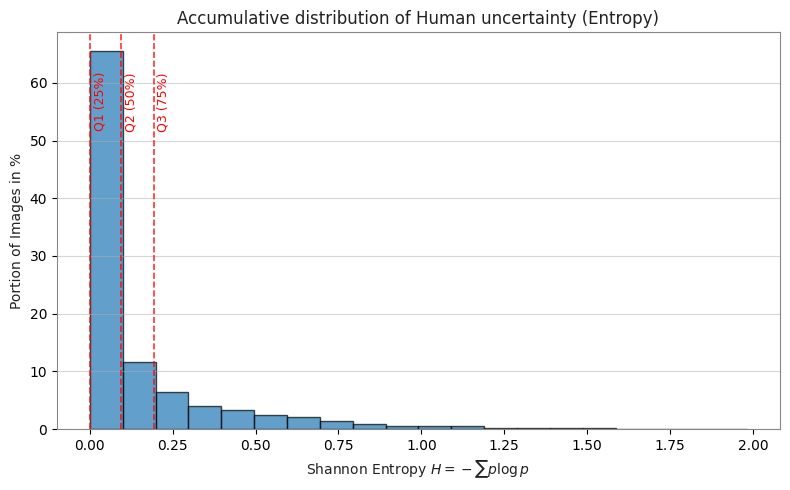

In [19]:
# histogram of entropy for different images
human_probs = test_dataset.human_probs.numpy()  # [N, 10]

# calculate Shannon Entropie 
probs_clipped = np.clip(human_probs, 1e-10, 1.0)
entropy = -np.sum(probs_clipped * np.log(probs_clipped), axis=1)

n_images = len(entropy)
weights  = np.ones_like(entropy) / n_images * 100

# plotting the figure
plt.figure(figsize=(8, 5))
plt.hist(entropy, bins=20, weights=weights, edgecolor='black', alpha=0.7)
plt.title('Accumulative distribution of Human uncertainty (Entropy)')
plt.xlabel('Shannon Entropy $H = -\sum p \log p$')
plt.ylabel('Portion of Images in %')
plt.grid(axis='y', alpha=0.5)

# visualize Quartiles
q25, q50, q75 = np.percentile(entropy, [25, 50, 75])
for q, label in zip([q25, q50, q75], ['Q1 (25%)', 'Q2 (50%)', 'Q3 (75%)']):
    plt.axvline(q, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
    plt.text(q + 0.01, plt.gca().get_ylim()[1] * 0.9, label,
             color='red', fontsize=9, rotation=90, va='top')

plt.tight_layout()
plt.show()

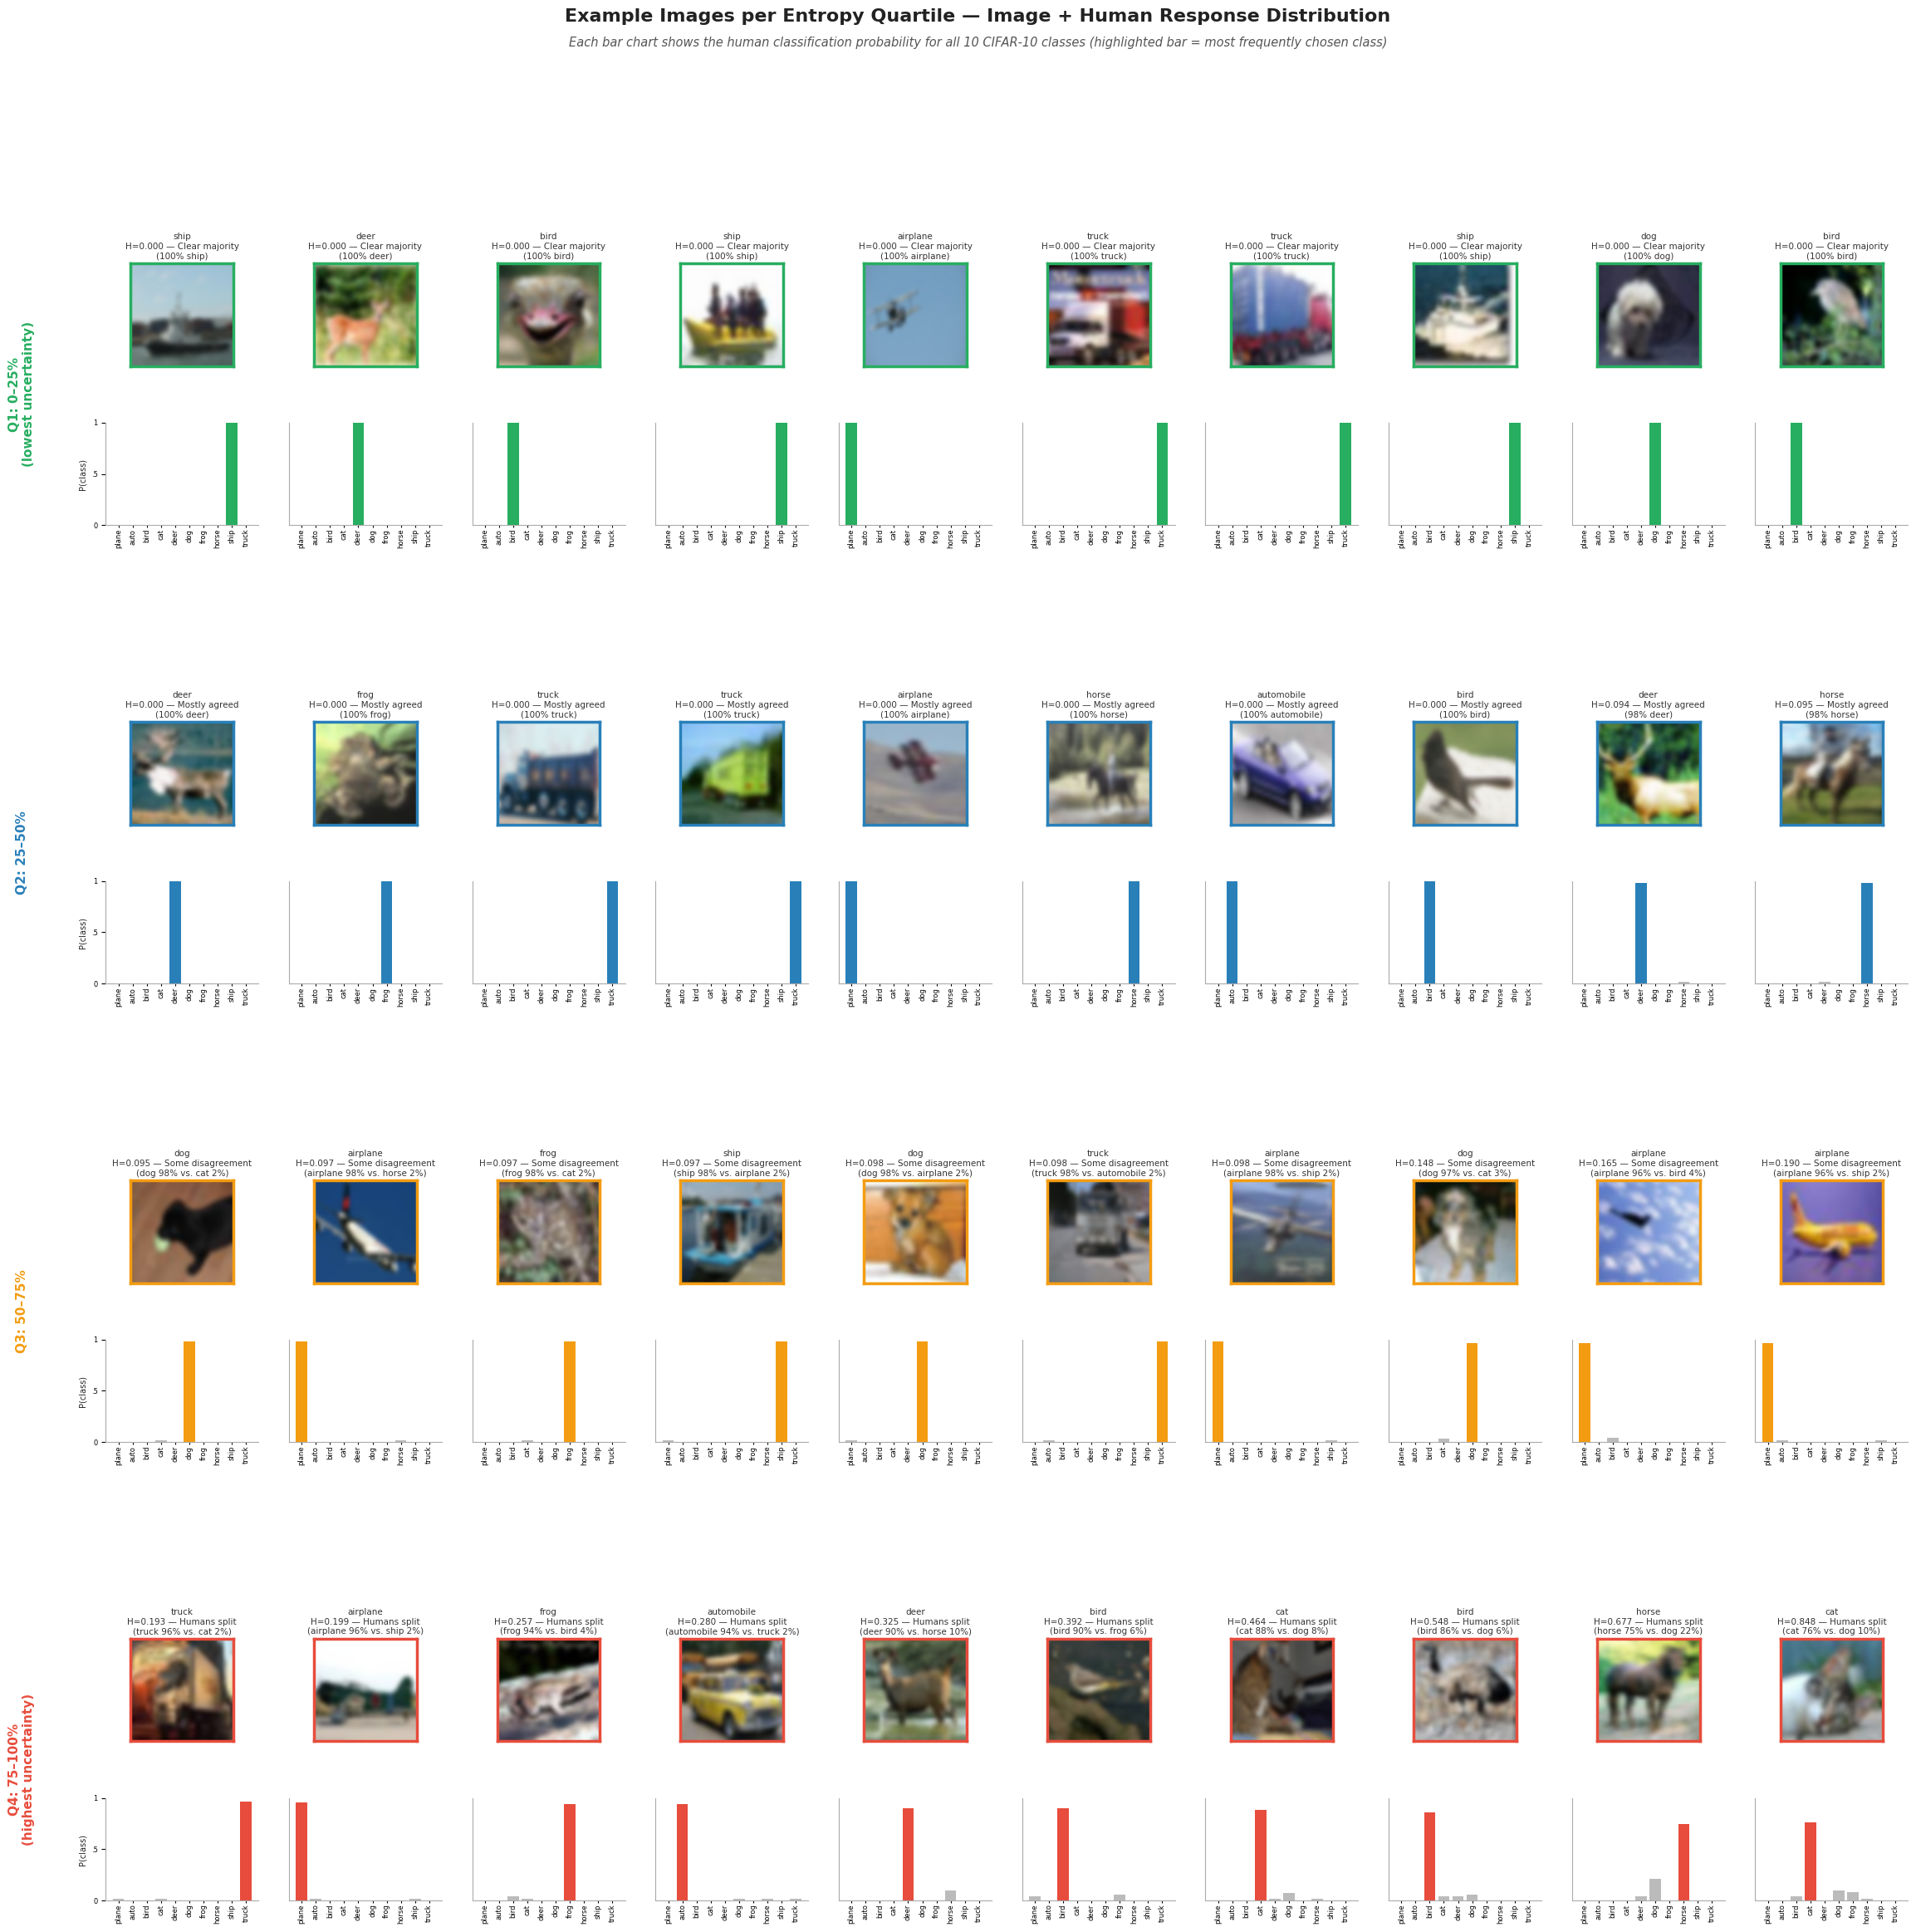

Saved: entropy_example_images.png


In [20]:
all_images_list = []
for img, _ in test_dataset:
    all_images_list.append(img)
all_images = torch.stack(all_images_list)  # [10000, 3, 32, 32]
 
# CONFIG
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
resize_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor()
])
 
# split Quartiles per Index
sorted_by_entropy = np.argsort(entropy)
n_total           = len(sorted_by_entropy)
split             = n_total // 4
bins = [
    (sorted_by_entropy[0        : split  ], "Q1: 0–25%\n(lowest uncertainty)"),
    (sorted_by_entropy[split    : split*2], "Q2: 25–50%"),
    (sorted_by_entropy[split*2  : split*3], "Q3: 50–75%"),
    (sorted_by_entropy[split*3  :        ], "Q4: 75–100%\n(highest uncertainty)"),
]
 
N_EXAMPLES = 10
 
# Colors per quartile
BIN_COLORS = ["#27AE60", "#2980B9", "#F39C12", "#E74C3C"]
 
# Short, quartile-specific framing for why the full probability distribution
# (not just the top-1 label) is informative — used as a prefix in each caption.
QUARTILE_HINT = [
    "Clear majority",     # Q1: one class dominates human responses
    "Mostly agreed",      # Q2: still a fairly dominant class
    "Some disagreement",  # Q3: probability mass starting to split
    "Humans split",       # Q4: multiple classes compete, ambiguous image
]
 
 
def caption_for(idx, quartile_row):
    """Builds a short caption that explains what the probability distribution
    reveals beyond the single top-1 label: whether humans agree on one class,
    or are split between visually/semantically similar classes."""
    probs = human_probs[idx]
    order = np.argsort(probs)[::-1]
    top1_cls, top2_cls = class_names[order[0]], class_names[order[1]]
    top1_p, top2_p = probs[order[0]], probs[order[1]]
    e_val = entropy[idx]
 
    hint = QUARTILE_HINT[quartile_row]
    if quartile_row <= 1:
        # low entropy: top class clearly dominates, second class is a footnote
        detail = f"{top1_p:.0%} {top1_cls}"
    else:
        # higher entropy: name the competing classes so it's clear WHY humans disagree
        detail = f"{top1_cls} {top1_p:.0%} vs. {top2_cls} {top2_p:.0%}"
 
    return f"{top1_cls}\nH={e_val:.3f} — {hint}\n({detail})"
 
 
# Abbreviated class labels so the rotated x-tick labels stay readable at this
# bar width (10 bars per histogram, ~10 histograms per row).
class_names_short = ["plane", "auto", "bird", "cat", "deer",
                      "dog", "frog", "horse", "ship", "truck"]
 
# PLOT ── each quartile gets 2 sub-rows: image row + (larger) histogram row
fig = plt.figure(figsize=(N_EXAMPLES * 2.8, 4 * 6.4))
outer_gs = gridspec.GridSpec(4, 1, figure=fig, hspace=0.75)
 
fig.suptitle(
    "Example Images per Entropy Quartile — Image + Human Response Distribution",
    fontsize=16, fontweight="bold", y=1.0
)
fig.text(
    0.5, 0.982,
    "Each bar chart shows the human classification probability for all 10 CIFAR-10 classes "
    "(highlighted bar = most frequently chosen class)",
    ha="center", fontsize=10.5, color="#555555", style="italic"
)
 
for row, (seg_indices, bin_label) in enumerate(bins):
    step     = max(1, len(seg_indices) // N_EXAMPLES)
    examples = seg_indices[::step][:N_EXAMPLES]
 
    # inner grid: 2 rows (image, histogram) x N_EXAMPLES columns, for this quartile.
    # Histogram row is now much taller (height_ratios) so the bars and the
    # rotated class-name x-ticks are clearly readable.
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, N_EXAMPLES, subplot_spec=outer_gs[row],
        height_ratios=[1.6, 1.6], hspace=0.55, wspace=0.2
    )
 
    for col, idx in enumerate(examples):
        # ── image ────────────────────────────────────────────────────
        ax_img = fig.add_subplot(inner_gs[0, col])
        img_tensor = all_images[idx]
        img_resized = resize_transform(img_tensor.cpu())
        img_np      = img_resized.permute(1, 2, 0).numpy()
        ax_img.imshow(img_np, interpolation="bicubic")
 
        ax_img.set_title(caption_for(idx, row), fontsize=7.5, pad=4, color="#333333")
 
        for spine in ax_img.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(BIN_COLORS[row])
            spine.set_linewidth(2.5)
        ax_img.set_xticks([])
        ax_img.set_yticks([])
 
        # 10-bar histogram of human response probabilities, with class-name
        #    x-tick labels so it's clear what the bars represent 
        ax_hist = fig.add_subplot(inner_gs[1, col])
        probs = human_probs[idx]
        top_class_idx = int(np.argmax(probs))
        bar_colors = ["#BBBBBB"] * len(class_names)
        bar_colors[top_class_idx] = BIN_COLORS[row]
        ax_hist.bar(range(len(class_names)), probs, color=bar_colors, width=0.8)
        ax_hist.set_ylim(0, 1.0)
        ax_hist.set_xticks(range(len(class_names)))
        ax_hist.set_xticklabels(class_names_short, fontsize=6, rotation=90)
        ax_hist.tick_params(axis="x", length=2, pad=1)
        if col == 0:
            ax_hist.set_yticks([0, 0.5, 1.0])
            ax_hist.set_yticklabels(["0", ".5", "1"], fontsize=6)
            ax_hist.set_ylabel("P(class)", fontsize=7)
        else:
            ax_hist.set_yticks([])
        for spine in ["top", "right"]:
            ax_hist.spines[spine].set_visible(False)
        for spine in ["left", "bottom"]:
            ax_hist.spines[spine].set_color("#AAAAAA")
 
    # quartile label to the left, spanning both sub-rows
    label_ax = fig.add_subplot(inner_gs[:, 0])
    label_ax.axis("off")
    label_ax.text(
        -0.55, 0.5, bin_label, transform=label_ax.transAxes,
        fontsize=11, fontweight="bold", color=BIN_COLORS[row],
        rotation=90, ha="center", va="center"
    )
 
plt.savefig("entropy_example_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: entropy_example_images.png")

In [ ]:
class PhilNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 (32x32)
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2),  # 16x16

            # Block 2 (16x16)
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2),  # 8x8

            # Block 3 (8x8)
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, 3, padding=1),  
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )


    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


In [ ]:
# Training and Evaluation Data tranformation and loading
# Train Images are normalized using the standard CIFAR-10 channel statistics. This improves generalization and prevents overfitting.

mean = (0.5, 0.5, 0.5)
std = (0.25, 0.25, 0.25)
transform_train = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomCrop(32, padding=4),
    T.AutoAugment(T.AutoAugmentPolicy.CIFAR10),
    T.ToTensor(),
    T.Normalize(mean, std)
])

# Only normalization is applied.
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std)
])

trainset = datasets.CIFAR10(root='data/', train=True, transform=transform_train, download=True)
testset = datasets.CIFAR10(root='data/', train=False, transform=transform_test, download=True)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128, shuffle=False)

In [ ]:
# Accuracy calculation function
def accuracy(output, target, topk=(1, 5)):
    """Compute the accuracy over the k top predictions for the specified values of k"""
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)

        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))

        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append(correct_k.mul_(100.0 / batch_size))
        return res

In [ ]:
def epoch_loop(model, db_loader, criterion, optimiser, epoch):
    """Runs one epoch through the data loader (train or eval)"""
    is_train = optimiser is not None
    model.train() if is_train else model.eval()

    accuracies_top1 = []
    accuracies_top5 = []
    losses = []

    start_time = time.time()

    with torch.set_grad_enabled(is_train):
        for batch_ind, (img, target) in enumerate(db_loader):
            img, target = img.to(device), target.to(device)
            output = model(img).squeeze()
            
            loss = criterion(output, target)

            # compute accuracy
            top1, top5 = accuracy(output, target, topk=(1, 5))
            losses.append(loss.item())
            accuracies_top1.append(top1.item())
            accuracies_top5.append(top5.item())

            # TENSORBOARD LOGGING
            if is_train:
                global_step = epoch * len(db_loader) + batch_ind

            # optimizer
            if is_train:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()

            # live progress
            if is_train and (batch_ind + 1) % 100 == 0:
                print(f"  [Batch {batch_ind+1}/{len(db_loader)}] "
                      f"Loss: {np.mean(losses):.4f} | "
                      f"Top-1: {np.mean(accuracies_top1):.2f}% | "
                      f"Top-5: {np.mean(accuracies_top5):.2f}%")

    epoch_time = time.time() - start_time
    
    return {
        'loss': np.mean(losses),
        'top1': np.mean(accuracies_top1),
        'top5': np.mean(accuracies_top5),
        'time': epoch_time
    }

In [ ]:
# Model setup
model = PhilNet().to(device)

# base learning rate 
base_lr = 0.005       
warmup_epochs = 5
epochs = 50

optimizer = optim.AdamW(
    model.parameters(),
    lr=base_lr,
    weight_decay=5e-4
)

scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

criterion = nn.CrossEntropyLoss()


# Training Procedure 


In [ ]:
# configuration
checkpoint_path = "philnet_checkpoint.pt"
best_model_path = "philnet_best.pt"

epochs = 50
start_epoch = 0
best_val_acc = 0.0

# Logs initialisieren
train_logs = {'acc1': [], 'acc5': [], 'loss': [], 'time': []}
val_logs = {'acc1': [], 'acc5': [], 'loss': [], 'time': []}


# SKIP TRAINING IF BEST MODEL EXISTS

if os.path.exists(best_model_path):
    print(f"Best model already exists: {best_model_path}")
    print("Skipping training.")

    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

else:

    # load checkpoint if exists
    if os.path.exists(checkpoint_path):
        print(f"found checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)

        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        if scheduler and checkpoint['scheduler_state_dict']:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        start_epoch = checkpoint['epoch']
        best_val_acc = checkpoint['best_val_acc']
        train_logs = checkpoint['train_logs']
        val_logs = checkpoint['val_logs']

        print(f"continue epoch {start_epoch+1}. Best Accuracy: {best_val_acc:.2f}%")

    else:
        print("no checkpoint")

    # TRAINING LOOP

    for epoch in range(start_epoch, epochs):

        print(f"\n=== Epoch {epoch+1}/{epochs} ===")

        train_log = epoch_loop(model, trainloader, criterion, optimizer, epoch)
        val_log = epoch_loop(model, testloader, criterion, None, epoch)

        if epoch < warmup_epochs:
            lr_scale = (epoch + 1) / warmup_epochs
            for param_group in optimizer.param_groups:
                param_group['lr'] = base_lr * lr_scale
        else:
            scheduler.step()

        # Logging
        train_logs['acc1'].append(train_log['top1'])
        train_logs['acc5'].append(train_log['top5'])
        train_logs['loss'].append(train_log['loss'])
        train_logs['time'].append(train_log['time'])

        val_logs['acc1'].append(val_log['top1'])
        val_logs['acc5'].append(val_log['top5'])
        val_logs['loss'].append(val_log['loss'])
        val_logs['time'].append(val_log['time'])

        current_lr = optimizer.param_groups[0]['lr']

        current_checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
            'best_val_acc': best_val_acc,
            'train_logs': train_logs,
            'val_logs': val_logs
        }

        # save checkpoint
        torch.save(current_checkpoint, checkpoint_path)

        # save best model
        if val_log['top1'] > best_val_acc:
            best_val_acc = val_log['top1']
            torch.save(current_checkpoint, best_model_path)
            print(f"New best Model! Val Top1: {best_val_acc:.2f}%")

    print("\n=== Training Finished ===")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

# Training Supervised Baselines (ResNet & ViT)

This section covers the supervised training of the ResNet-50 and ViT-B/16 architectures. These models serve as performance baselines for the representation alignment analysis. To train a specific architecture, simply adjust the model_used and checkpoint_path parameter within the training block to toggle between resnet and vit.

In [ ]:
def get_vit_model(num_classes=10):
    # 1. load ViT_B_16 with Imagenet weights
    model = models.vit_b_16(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    print(model)

    # 2. adapt classifier head to cifar from imagenet
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    
    return model.to(device)

In [ ]:
def get_resnet50_model(num_classes=10):
    # Load ResNet50 with ImageNet weights
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    print(model)

    # adapt final layer for cifar classes
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    return model.to(device)

In [ ]:
# data transformation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mean = (0.5071, 0.4867, 0.4408)
std = (0.2675, 0.2565, 0.2761)

transform_train = T.Compose([
    T.Resize((224, 224),  interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(),
    T.AutoAugment(T.AutoAugmentPolicy.CIFAR10),
    T.ToTensor(),
    T.Normalize(mean, std)
])

transform_test = T.Compose([
    T.Resize((224, 224),  interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean, std)
])

trainloader = DataLoader(datasets.CIFAR10('data/', train=True, transform=transform_train, download=True), 
                         batch_size=32, shuffle=True, num_workers=4)
testloader = DataLoader(datasets.CIFAR10('data/', train=False, transform=transform_test, download=True), 
                        batch_size=32, shuffle=False, num_workers=4)

In [7]:
# Training loop function
def epoch_loop(model, db_loader, criterion, optimiser, epoch):
    is_train = optimiser is not None
    model.train() if is_train else model.eval()

    accuracies_top1 = []
    losses = []
    start_time = time.time()

    with torch.set_grad_enabled(is_train):
        for batch_ind, (img, target) in enumerate(db_loader):
            img, target = img.to(device), target.to(device)
            
            output = model(img)
            loss = criterion(output, target)

            # Accuracy calculation
            top1, _ = accuracy(output, target, topk=(1, 5))
            losses.append(loss.item())
            accuracies_top1.append(top1.item())

            if is_train:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()

            if is_train and (batch_ind + 1) % 100 == 0:
                print(f"  [Batch {batch_ind+1}/{len(db_loader)}] Loss: {np.mean(losses):.4f} | Top-1: {np.mean(accuracies_top1):.2f}%")

    return {'loss': np.mean(losses), 'top1': np.mean(accuracies_top1), 'time': time.time() - start_time}

In [ ]:
# start training
model_used = get_vit_model(num_classes=10)
epochs = 50
optimizer = optim.AdamW(model_used.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
criterion = nn.CrossEntropyLoss()

best_acc = 0.0
start_epoch = 0
# Training Configuration
last_checkpoint_path = "vit_last.pth"
best_model_path = "vit_supervised_run1.pth"

# 1. Load checkpoint if it exists to resume training
if os.path.exists(last_checkpoint_path):
    print(f"Loading checkpoint: {last_checkpoint_path}")
    checkpoint = torch.load(last_checkpoint_path)
    
    # Map the state to the current model, optimizer, and scheduler
    model_used.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint.get('best_acc', 0.0)
    
    print(f"Resuming from Epoch {start_epoch + 1} (Previous best accuracy: {best_acc:.2f}%)")
else:
    print("No checkpoint found. Starting training from scratch.")

# Training & Validation Loop
for epoch in range(start_epoch, epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    
    # Execute training and evaluation for the current epoch
    train_res = epoch_loop(model_used, trainloader, criterion, optimizer, epoch)
    val_res = epoch_loop(model_used, testloader, criterion, None, epoch)
    
    # Update learning rate based on the scheduler
    scheduler.step()
    
    # 2. Save the "Latest" state for potential resume
    # We save the full state including optimizer and scheduler for continuity
    checkpoint_state = {
        'epoch': epoch,
        'model_state_dict': model_used.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_acc': best_acc
    }
    torch.save(checkpoint_state, last_checkpoint_path)

    # 3. Track and save the "Best" model based on Validation Accuracy
    # If the current epoch outperforms previous ones, we save a dedicated 'best' file
    current_acc = val_res['top1']
    if current_acc > best_acc:
        best_acc = current_acc
        # We only save the state_dict here for easy inference later
        torch.save(model_used.state_dict(), best_model_path)
        print(f">>> New Best Performance! Acc: {best_acc:.2f}% | Model saved to {best_model_path}")

    print(f"Summary | Val Acc: {current_acc:.2f}% | Checkpoint updated.")

print(f"\nTraining completed. Highest accuracy reached: {best_acc:.2f}%")

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

/tmp/ipykernel_3986942/1034204125.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(last_checkpoint_path)


Resuming from Epoch 14 (Previous best accuracy: 73.63%)

Epoch 14/15
  [Batch 100/1563] Loss: 0.7999 | Top-1: 71.78%
  [Batch 200/1563] Loss: 0.7695 | Top-1: 72.88%
  [Batch 300/1563] Loss: 0.7548 | Top-1: 73.34%
  [Batch 400/1563] Loss: 0.7561 | Top-1: 73.22%
  [Batch 500/1563] Loss: 0.7537 | Top-1: 73.52%
  [Batch 600/1563] Loss: 0.7551 | Top-1: 73.29%
  [Batch 700/1563] Loss: 0.7566 | Top-1: 73.25%
  [Batch 800/1563] Loss: 0.7608 | Top-1: 73.11%
  [Batch 900/1563] Loss: 0.7558 | Top-1: 73.28%
  [Batch 1000/1563] Loss: 0.7570 | Top-1: 73.28%
  [Batch 1100/1563] Loss: 0.7548 | Top-1: 73.32%
  [Batch 1200/1563] Loss: 0.7562 | Top-1: 73.25%
  [Batch 1300/1563] Loss: 0.7547 | Top-1: 73.36%
  [Batch 1400/1563] Loss: 0.7565 | Top-1: 73.32%
  [Batch 1500/1563] Loss: 0.7553 | Top-1: 73.36%
>>> New Best Performance! Acc: 75.59% | Model saved to vit_untrained_supervised_run1.pth
Summary | Val Acc: 75.59% | Checkpoint updated.

Epoch 15/15
  [Batch 100/1563] Loss: 0.7117 | Top-1: 74.81%
  [Batc

# Generative Image Captioning for CLIP

To prepare the dataset for CLIP training, we generate three unique captions per CIFAR-10 image using a generative model. This process is computationally intensive and should be executed via TMUX to ensure persistence during long-running sessions (e.g., python Captions.py).
Once the generation is complete, the resulting JSON dictionary can be loaded and verified using the following utility code to visualize the alignment between the images and their generated descriptions.

In [ ]:
test_captions="cifar10_test_captions.json"
captions_dict = {}

print(f"Load test captions: '{test_captions}'.")
with open(test_captions, "r") as f:
    captions_dict = json.load(f)

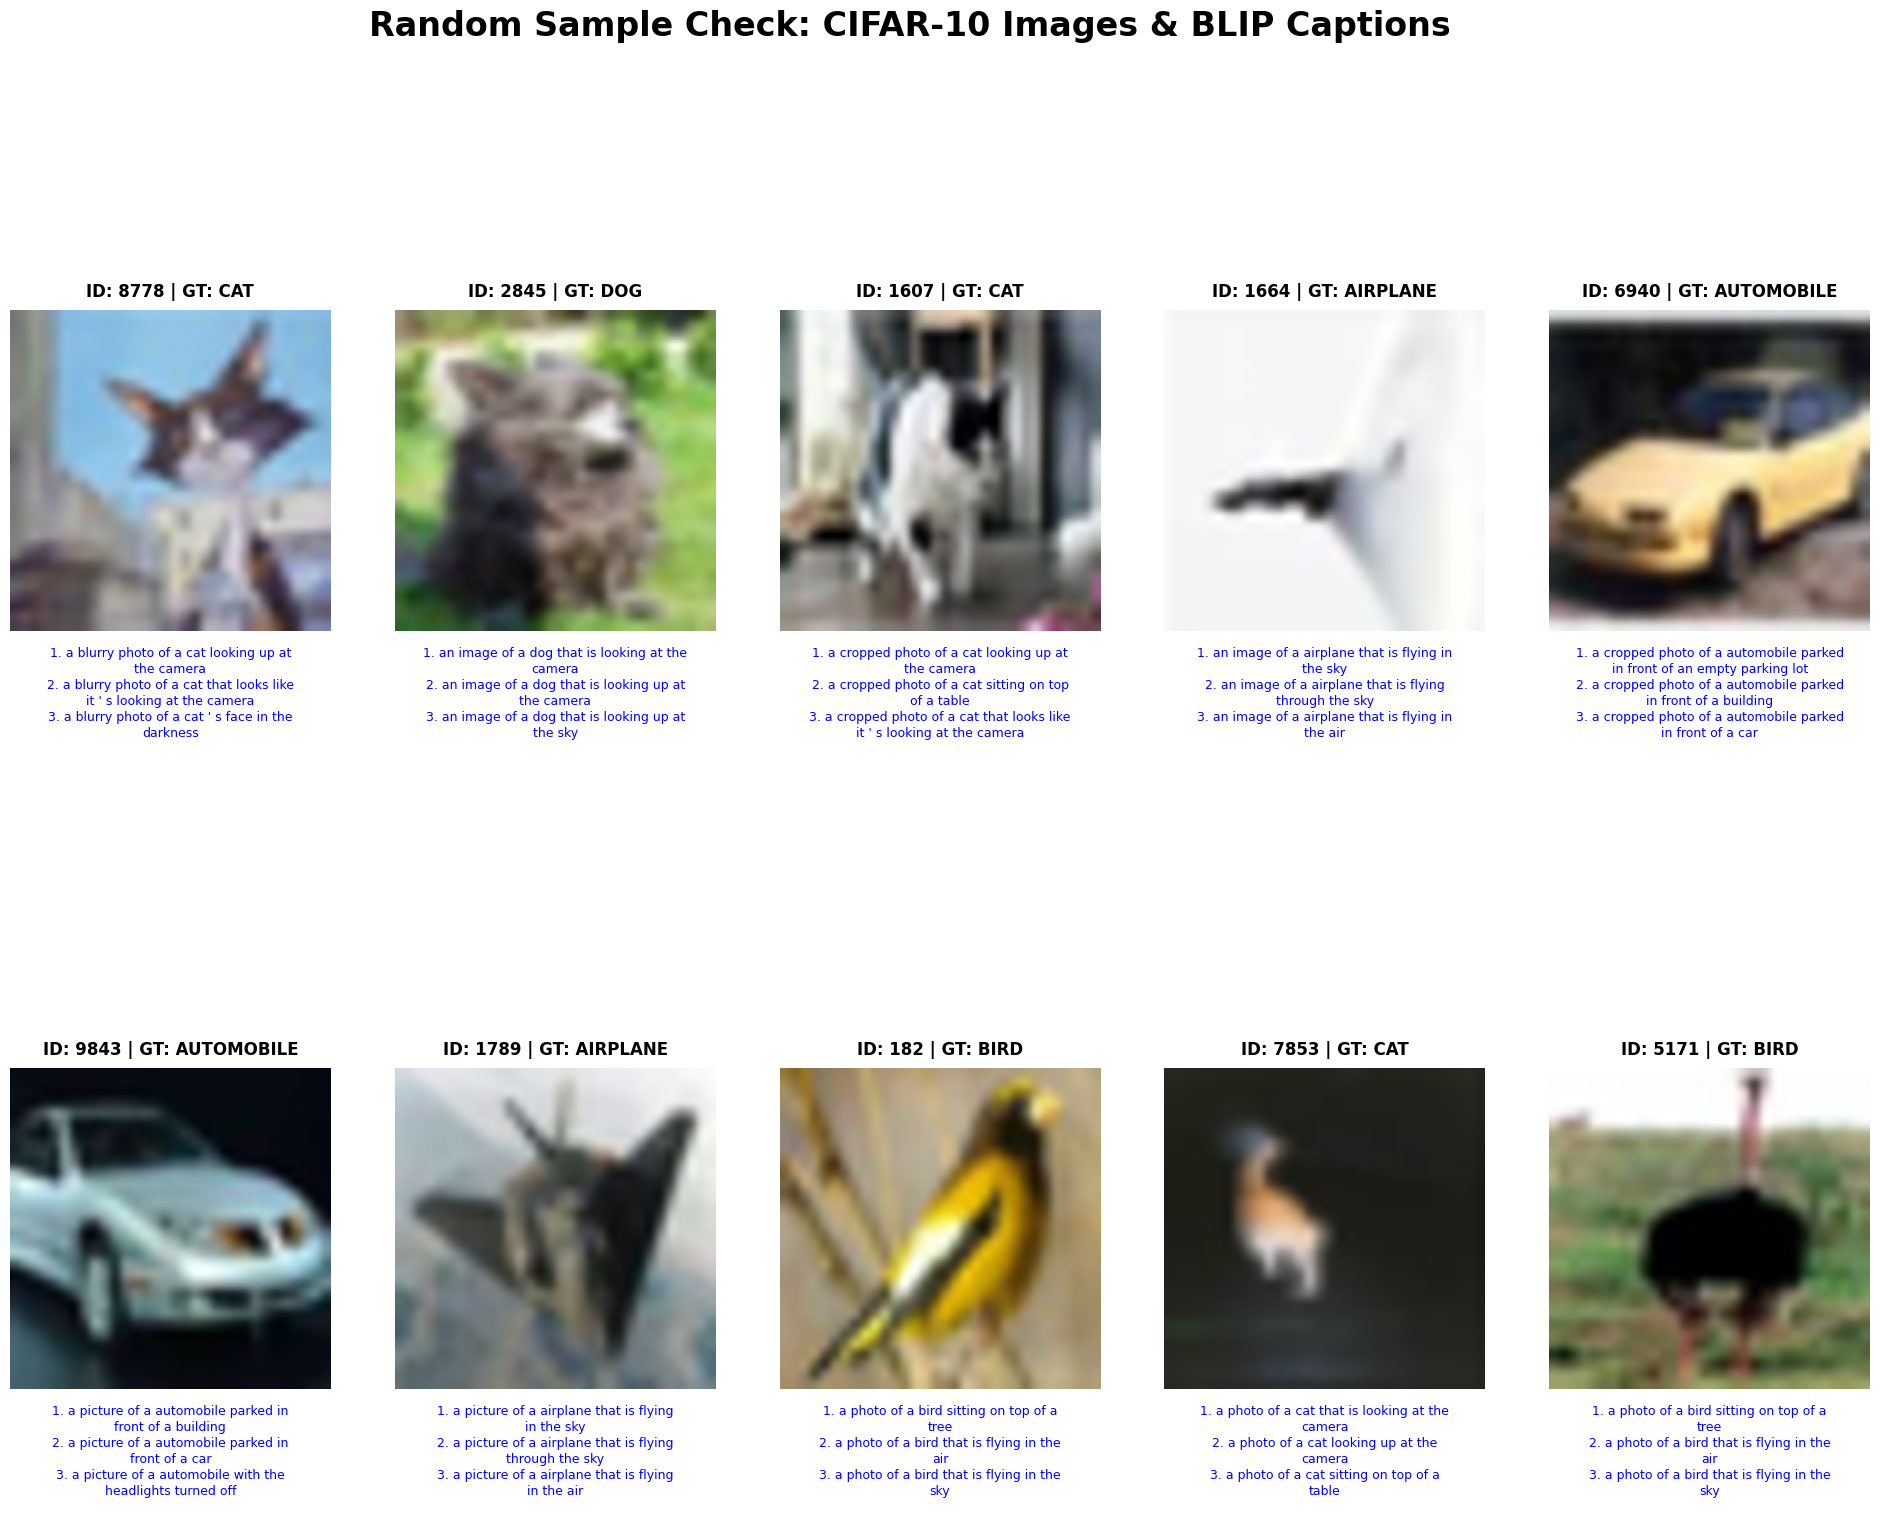

In [5]:
def plot_random_samples(dataset, captions_dict, n=10):
    
    # 2. choose random indices in dataset
    total_samples = len(dataset)
    random_indices = random.sample(range(total_samples), n)
    
    # Preview transform 
    preview_transform = T.Compose([
        T.ToPILImage(),
        T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC)
    ])

    rows = 2
    cols = n // rows
    fig, axes = plt.subplots(rows, cols, figsize=(24, 16))
    axes = axes.flatten() # Macht das Handling einfacher

    for i, idx in enumerate(random_indices):
        idx_str = str(idx)
        img_tensor, gt_label = dataset[idx]
        
        # Captions from dictionary
        caption_data = captions_dict.get(idx_str, {"captions": ["N/A"]})
        all_captions = caption_data.get("captions", ["N/A"])

        # formate Captions 
        formatted_captions = ""
        for j, cap in enumerate(all_captions[:3]): 
            wrapped = textwrap.fill(cap, width=40)
            formatted_captions += f"{j+1}. {wrapped}\n"
            
        label_name = dataset.classes[gt_label]
    
        img_pil = preview_transform(torch.clamp(img_tensor, 0, 1))
        
        ax = axes[i]
        ax.imshow(img_pil)
        ax.axis('off')
        
        # Titel with GT label and entropy score
        ax.set_title(f"ID: {idx} | GT: {label_name.upper()}", 
                     fontsize=12, fontweight='bold', pad=10)
        
        ax.text(0.5, -0.05, formatted_captions, transform=ax.transAxes, 
                ha='center', va='top', fontsize=9, color='blue', 
                fontweight='medium', linespacing=1.3)

    plt.suptitle("Random Sample Check: CIFAR-10 Images & BLIP Captions", 
                 fontsize=24, y=1.02, fontweight='bold')
    
    plt.subplots_adjust(hspace=0.6) 
    plt.show()

# show 10 random images
plot_random_samples(cifar10_test, captions_dict, n=10)

## Plotting to check for valid captions

Despite generating multiple captions per image, the semantic diversity remained relatively constrained. This is primarily attributed to the low native resolution of CIFAR-10 ($32 \times 32$ pixels). Although bicubic interpolation was used to upscale images to $224 \times 224$ for model compatibility, the lack of fine-grained visual details limited the generative model's (BLIP) ability to produce highly distinct descriptions. However, for the purpose of semantic grounding, the generated captions provided a sufficient conceptual anchor to resolve visual ambiguities.

# Accuracy

Saved: accuracy_trained_models.png
Saved: accuracy_off_the_shelf_models.png


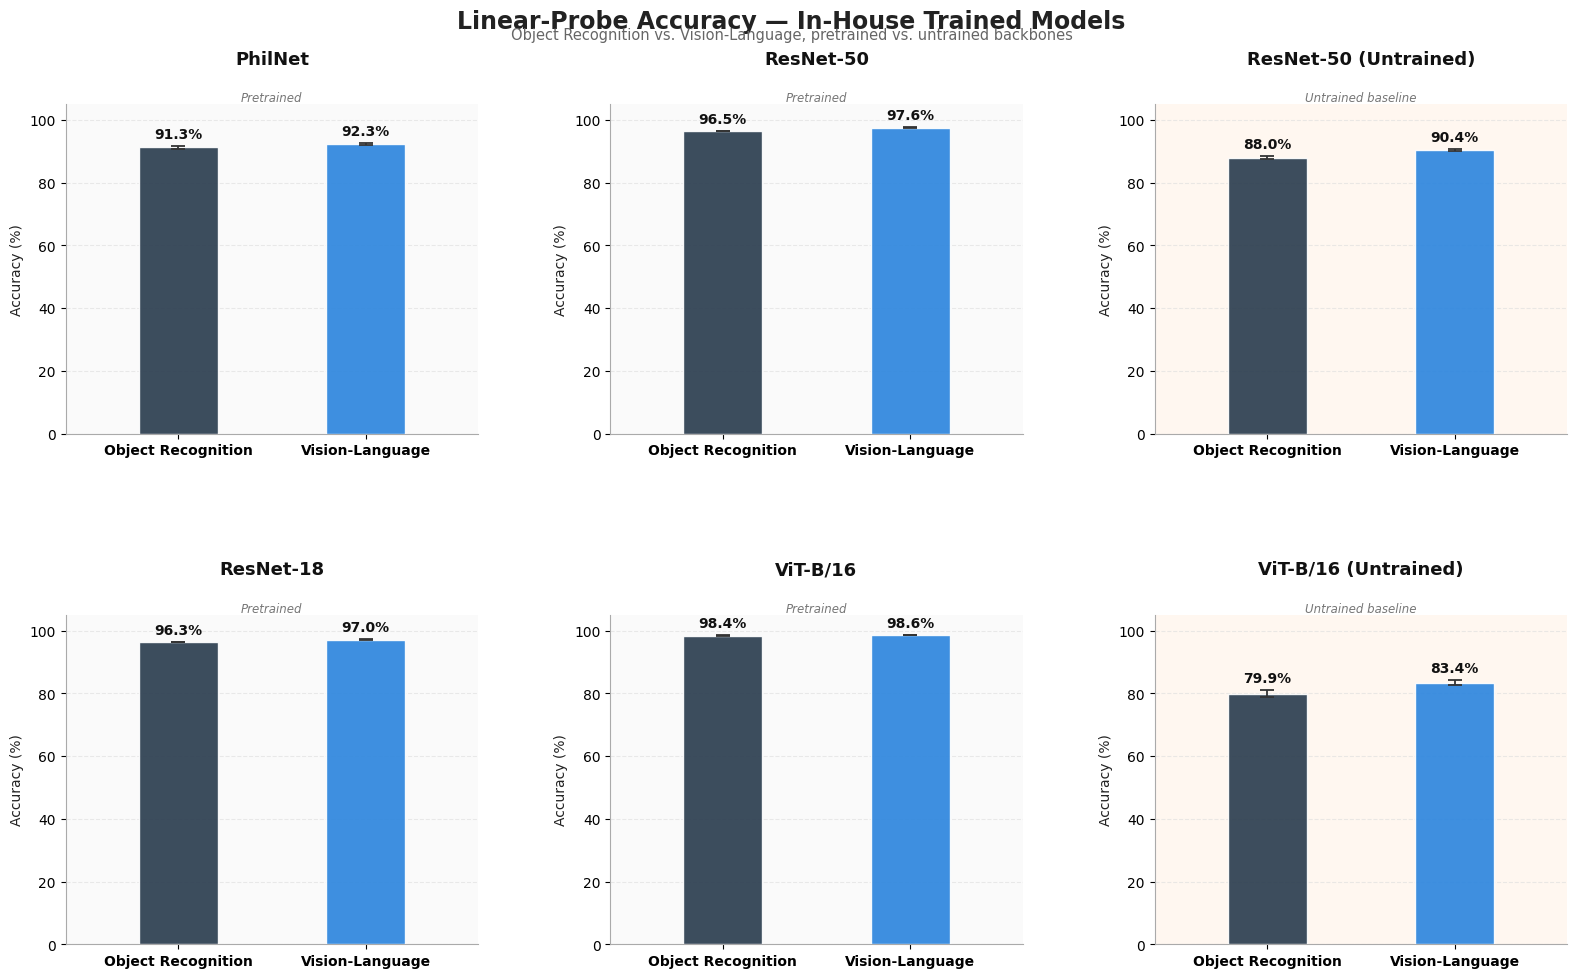

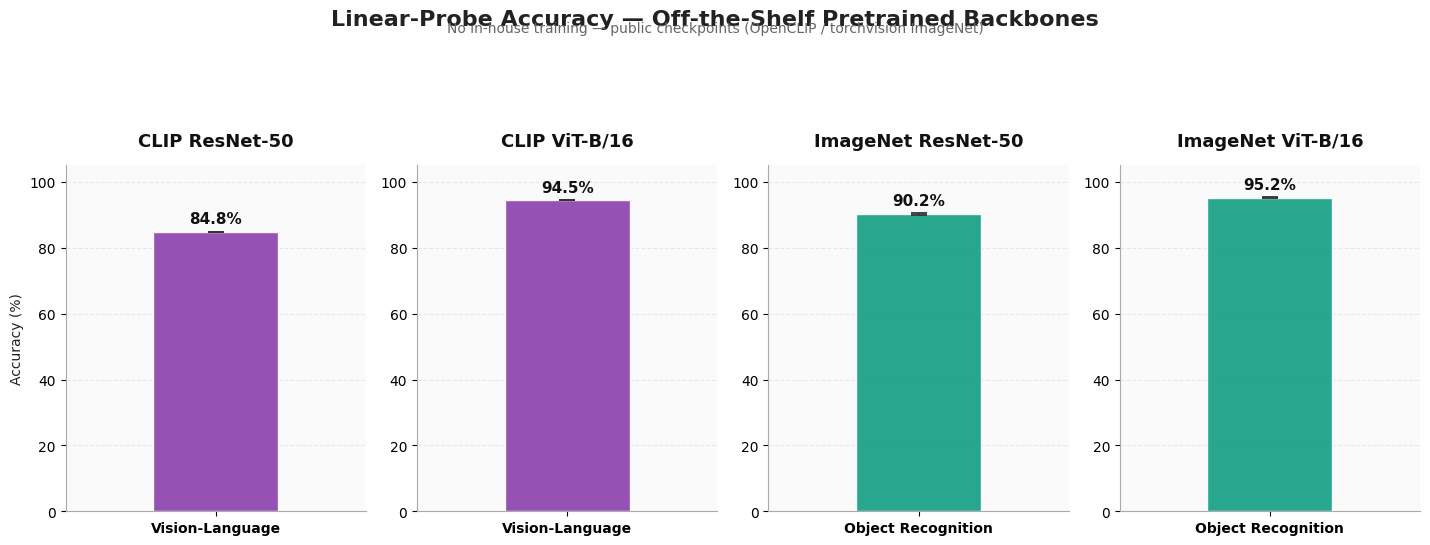

In [3]:
# 1. CONFIG

# Group 1: the original 6 trained-in-house models
TRAINED_MODELS = ["philnet", "resnet", "resnet_untrained", "resnet18", "vit", "vit_untrained"]

# Group 2: off-the-shelf pretrained backbones 
OFF_THE_SHELF_MODELS = [
    {"tag": "resnet50_clip",     "label": "CLIP ResNet-50",  "paradigm": "clip"},
    {"tag": "vit_b16_clip",      "label": "CLIP ViT-B/16",   "paradigm": "clip"},
    {"tag": "resnet50_imagenet", "label": "ImageNet ResNet-50", "paradigm": "supervised"},
    {"tag": "vit_b16_imagenet",  "label": "ImageNet ViT-B/16",  "paradigm": "supervised"},
]

paradigms = ["supervised", "clip"]
names_paradigms = ["Object Recognition", "Vision-Language"]
paradigm_display = dict(zip(paradigms, names_paradigms))

acc_dir = "./out/accuracy_results/"

MODEL_LABELS = {
    "philnet": "PhilNet",
    "resnet": "ResNet-50",
    "resnet_untrained": "ResNet-50 (Untrained)",
    "resnet18": "ResNet-18",
    "vit": "ViT-B/16",
    "vit_untrained": "ViT-B/16 (Untrained)",
}

colors = {"supervised": "#2C3E50", "clip": "#2E86DE"}
OFF_SHELF_COLOR = {"clip": "#8E44AD", "supervised": "#16A085"}

BG_COLOR = "#FAFAFA"
GRID_COLOR = "#DDDDDD"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#888888",
    "axes.labelcolor": "#222222",
    "text.color": "#222222",
})


def load_acc(tag):
    path = os.path.join(acc_dir, f"{tag}_final_metrics.json")
    if not os.path.exists(path):
        print(f"[WARN] Data not found: {path}")
        return None
    with open(path) as f:
        return json.load(f)


def style_axis(ax, title, subtitle=None):
    ax.set_facecolor(BG_COLOR)
    ax.grid(axis="y", linestyle="--", alpha=0.6, color=GRID_COLOR, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#AAAAAA")
    title_text = title if not subtitle else f"{title}\n"
    ax.set_title(title_text, fontsize=13, pad=14, weight="bold", color="#111111")
    if subtitle:
        ax.text(0.5, 1.0, subtitle, transform=ax.transAxes, ha="center", va="bottom",
                fontsize=8.5, color="#777777", style="italic")


def draw_paradigm_bars(ax, acc_dict, bar_colors, width=0.42):
    present_paradigms = [p for p in paradigms if p in acc_dict]
    x = np.arange(len(present_paradigms))
    for i, p in enumerate(present_paradigms):
        stats = acc_dict[p]
        mean_v = stats.get("mean", 0)
        std_v = stats.get("std", 0)
        ax.bar(i, mean_v, width=width, color=bar_colors[p], alpha=0.92,
               edgecolor="white", linewidth=1.0, zorder=3)
        ax.errorbar(i, mean_v, yerr=std_v, fmt="none", ecolor="#333333",
                    lw=1.3, capsize=5, capthick=1.3, zorder=4)
        ax.text(i, mean_v + std_v + 1.5, f"{mean_v:.1f}%", ha="center", va="bottom",
                fontsize=10, weight="semibold", color="#111111")
    ax.set_xticks(x)
    ax.set_xticklabels([paradigm_display[p] for p in present_paradigms],
                        fontsize=10, weight="semibold")
    ax.set_xlim(-0.6, len(present_paradigms) - 0.4 if len(present_paradigms) > 1 else 0.6)
    ax.set_ylim(0, 105)


# 2. SECTION 1 — trained-in-house models (pretrained vs. untrained), grid layout

n_trained = len(TRAINED_MODELS)
n_cols = 3
n_rows = int(np.ceil(n_trained / n_cols))

fig1 = plt.figure(figsize=(5.5 * n_cols, 4.6 * n_rows + 0.8))
fig1.suptitle("Linear-Probe Accuracy — In-House Trained Models",
               fontsize=17, fontweight="bold", y=0.995)
fig1.text(0.5, 0.965, "Object Recognition vs. Vision-Language, pretrained vs. untrained backbones",
           ha="center", fontsize=10.5, color="#666666")

gs1 = gridspec.GridSpec(n_rows, n_cols, figure=fig1, hspace=0.55, wspace=0.32,
                          top=0.90, bottom=0.06, left=0.06, right=0.97)

for idx, m in enumerate(TRAINED_MODELS):
    acc_dict = load_acc(m)
    ax = fig1.add_subplot(gs1[idx // n_cols, idx % n_cols])
    label = MODEL_LABELS.get(m, m.upper())
    is_untrained = "untrained" in m
    subtitle = "Untrained baseline" if is_untrained else "Pretrained"

    if acc_dict is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes,
                fontsize=11, color="#AAAAAA")
        style_axis(ax, label, subtitle)
        continue

    draw_paradigm_bars(ax, acc_dict, colors)
    style_axis(ax, label, subtitle)
    ax.set_ylabel("Accuracy (%)", fontsize=10)

    # subtle background tint to visually separate untrained baselines
    if is_untrained:
        ax.set_facecolor("#FFF7F0")

plt.savefig("accuracy_trained_models.png", dpi=150, bbox_inches="tight")
print("Saved: accuracy_trained_models.png")

# 3. SECTION 2 — off-the-shelf pretrained models (single paradigm each)

n_off = len(OFF_THE_SHELF_MODELS)
fig2, axes2 = plt.subplots(1, n_off, figsize=(3.6 * n_off, 5.2))
if n_off == 1:
    axes2 = [axes2]

fig2.suptitle("Linear-Probe Accuracy — Off-the-Shelf Pretrained Backbones",
               fontsize=16, fontweight="bold", y=1.04)
fig2.text(0.5, 0.995, "No in-house training — public checkpoints (OpenCLIP / torchvision ImageNet)",
           ha="center", fontsize=10, color="#666666")

for idx, cfg in enumerate(OFF_THE_SHELF_MODELS):
    ax = axes2[idx]
    acc_dict = load_acc(cfg["tag"])
    p = cfg["paradigm"]
    bar_color = OFF_SHELF_COLOR[p]

    if acc_dict is None or p not in acc_dict:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes,
                fontsize=11, color="#AAAAAA")
        style_axis(ax, cfg["label"], paradigm_display[p])
        continue

    stats = acc_dict[p]
    mean_v = stats.get("mean", 0)
    std_v = stats.get("std", 0)

    ax.bar(0, mean_v, width=0.5, color=bar_color, alpha=0.92,
           edgecolor="white", linewidth=1.0, zorder=3)
    ax.errorbar(0, mean_v, yerr=std_v, fmt="none", ecolor="#333333",
                lw=1.3, capsize=6, capthick=1.3, zorder=4)
    ax.text(0, mean_v + std_v + 1.5, f"{mean_v:.1f}%", ha="center", va="bottom",
            fontsize=11, weight="semibold", color="#111111")

    ax.set_xticks([0])
    ax.set_xticklabels([paradigm_display[p]], fontsize=10, weight="semibold")
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(0, 105)
    style_axis(ax, cfg["label"])
    if idx == 0:
        ax.set_ylabel("Accuracy (%)", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("accuracy_off_the_shelf_models.png", dpi=150, bbox_inches="tight")
print("Saved: accuracy_off_the_shelf_models.png")

plt.show()

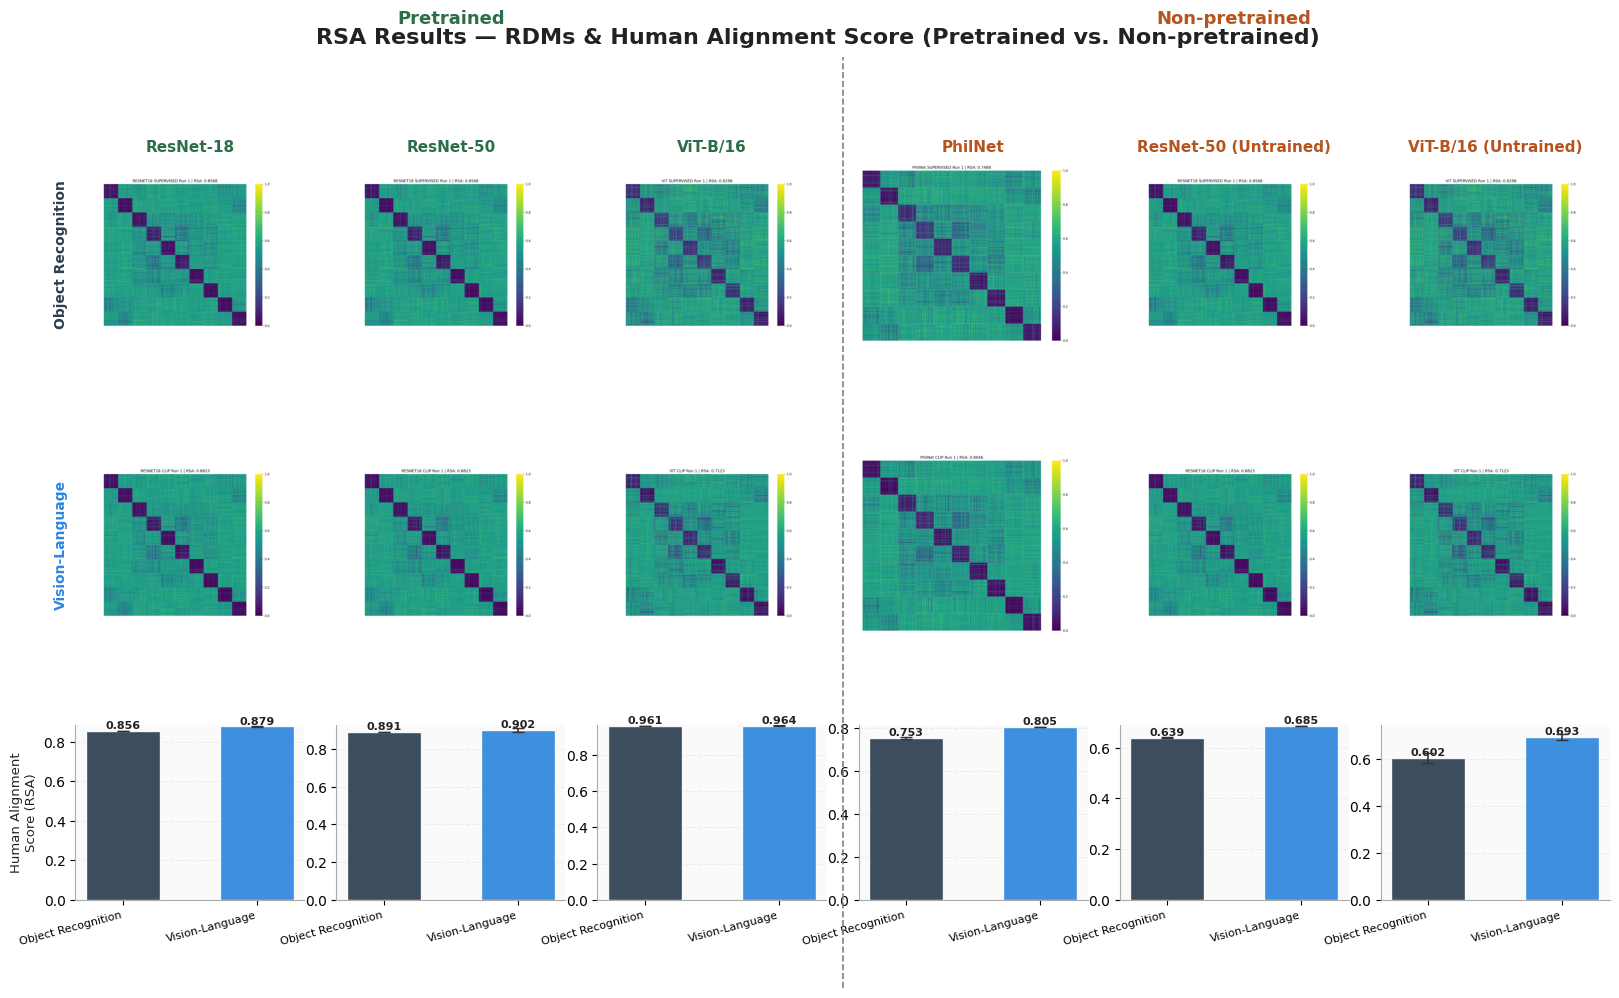

=== Paradigm averages (Human Alignment Score / RSA, averaged over all 6 networks) ===
Object Recognition   scores=[0.8558361343239969, 0.8910928093722221, 0.9609, 0.7532, 0.6386788317687436, 0.6021] -> avg = 0.7836, sd = 0.1436
Vision-Language      scores=[0.8787118667828627, 0.9018019930622804, 0.9635, 0.8049, 0.6850886024542163, 0.6929] -> avg = 0.8212, sd = 0.1143

=== Statistical comparison: Object Recognition vs. Vision-Language (n=6, paired) ===
[PRIMARY]  Wilcoxon signed-rank:  W = 0.0000, p = 0.0312
[secondary] Paired t-test:          t = -2.8301, p = 0.0367
[secondary] Sign-permutation test:   observed diff = -0.0375, p = 0.0312
[secondary] Cohen's d (paired):      d = -1.1554

Note: n=6 paired observations. Per RSA methodology guidance (Nili et al., 2014), the Wilcoxon signed-rank result above is the primary reference; other tests and the effect size are supplementary.

=== Group averages (Human Alignment Score, averaged over both paradigms) ===
Pretrained     (resnet18, resn

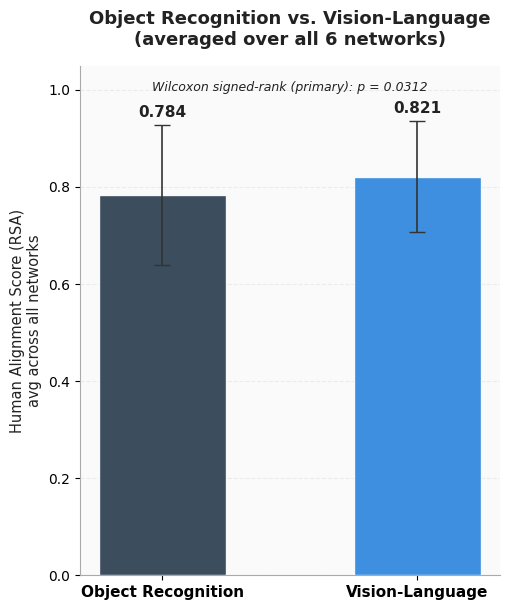

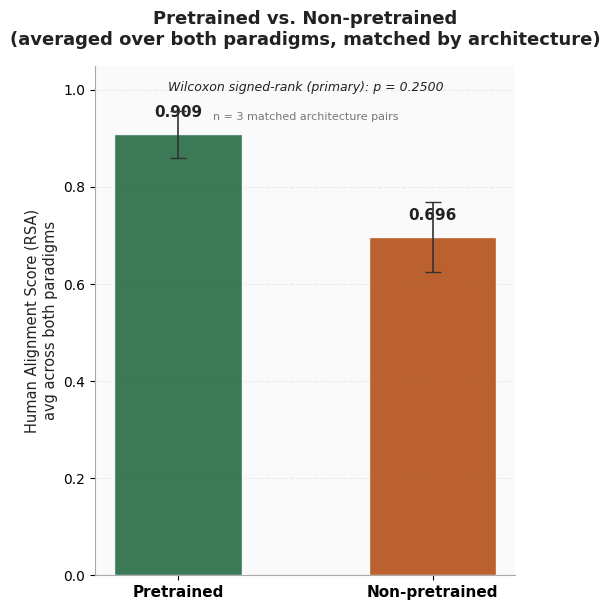

In [10]:

# 1. CONFIG

# Models grouped: pretrained block first, non-pretrained block second.

PRETRAINED_MODELS = ["resnet18", "resnet", "vit"]
NON_PRETRAINED_MODELS = ["philnet", "resnet_untrained", "vit_untrained"]
models = PRETRAINED_MODELS + NON_PRETRAINED_MODELS

# Slightly deeper / more legible palette than the original flat colors.
GROUP_COLORS = {"pretrained": "#2C6E49", "non_pretrained": "#B5541E"}

BG_COLOR = "#FAFAFA"
GRID_COLOR = "#DDDDDD"

x = np.arange(len(paradigms))
WIDTH = 0.55
GROUP_LABELS = {"pretrained": "Pretrained", "non_pretrained": "Non-pretrained"}

# Off-the-shelf pretrained backbones (no in-house training) — produced by
# openclip_rn50_rsa_full.py, openclip_vitb16_rsa_full.py,
# imagenet_resnet50_rsa_full.py, imagenet_vitb16_rsa_full.py. These have no
# "untrained" counterpart, so they are NOT included in the architecture-paired
# Pretrained-vs-Non-pretrained Wilcoxon comparisons (which require matched
# pairs). They ARE included as a third category in the Kruskal-Wallis omnibus
# test below, where each contributes its single paradigm score as a
# (one-observation) group.

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#888888",
})


# Path mapping per model (pointing untrained models + resnet18 to the shared resnet folder)
def get_rsa_dir(model):
    base_folder = (
        model
        .replace("_untrained", "")
        .replace("untrained", "")
        .replace("18", "")
    )
    return f"./out/rsa_results_{base_folder}/"


def model_group(model):
    return "pretrained" if model in PRETRAINED_MODELS else "non_pretrained"


def style_bar_axis(ax):
    ax.set_facecolor(BG_COLOR)
    ax.grid(axis="y", linestyle="--", alpha=0.5, color=GRID_COLOR, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#AAAAAA")


# 2. FIGURE — RDM matrix (rows = paradigms) + accuracy row, columns grouped
#    into Pretrained | Non-pretrained blocks with a visual separator.

n_models = len(models)
n_rows = len(paradigms) + 1  # RDM rows + 1 accuracy row

fig, axes = plt.subplots(
    n_rows, n_models,
    figsize=(3.3 * n_models, 3.3 * len(paradigms) + 3.2),
    gridspec_kw={"height_ratios": [2] * len(paradigms) + [1.6],
                 "hspace": 0.35, "wspace": 0.14},
    squeeze=False,
)
fig.suptitle("RSA Results — RDMs & Human Alignment Score (Pretrained vs. Non-pretrained)",
             fontsize=16, fontweight="bold", y=1.0)

# store per-model, per-paradigm means for the group comparison later
model_means = {m: {} for m in models}
model_stds = {m: {} for m in models}

for idx, m in enumerate(models):
    rsa_dir = get_rsa_dir(m)
    group = model_group(m)

    # RDM rows
    for p_idx, p in enumerate(paradigms):
        match = next(
            (f for f in sorted(os.listdir(rsa_dir))
             if f.startswith(f"rdm_{p}_")
             and f.endswith(".png")
             and not f.endswith("_amb.png")),
            None
        ) if os.path.isdir(rsa_dir) else None

        if "untrained" in m:
            match_untrained = next(
                (f for f in sorted(os.listdir(rsa_dir))
                 if f.startswith(f"rdm_{p}_")
                 and "untrained" in f.lower()
                 and f.endswith(".png")
                 and not f.endswith("_amb.png")),
                None
            ) if os.path.isdir(rsa_dir) else None
            if match_untrained:
                match = match_untrained

        ax = axes[p_idx, idx]
        if match:
            ax.imshow(mpimg.imread(os.path.join(rsa_dir, match)))
        else:
            ax.text(0.5, 0.5, f"{paradigm_display[p]}\nnot found",
                    ha="center", va="center", transform=ax.transAxes, fontsize=8, color="#999999")
        ax.axis("off")

        # Paradigm label, leftmost column only
        if idx == 0:
            ax.set_ylabel(paradigm_display[p], fontsize=10, fontweight="bold",
                          color=colors[p], rotation=90, labelpad=5)
            ax.yaxis.set_label_position("left")
            ax.axis("on")
            ax.set_yticks([])
            ax.set_xticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

        # Model title, top row only, colored by group
        if p_idx == 0:
            label = MODEL_LABELS.get(m, m.upper())
            ax.set_title(label, fontsize=11, fontweight="bold", pad=8,
                         color=GROUP_COLORS[group])

    # alignment-score row 
    acc_ax = axes[len(paradigms), idx]
    json_path = os.path.join(rsa_dir, f"summary_{m}.json")

    means, stds = [], []
    if os.path.isfile(json_path):
        with open(json_path) as f:
            rsa_dict = json.load(f)
        means = [rsa_dict.get(p, {}).get("mean", np.nan) for p in paradigms]
        stds = [rsa_dict.get(p, {}).get("std", 0) for p in paradigms]
    else:
        means = [np.nan] * len(paradigms)
        stds = [0] * len(paradigms)
        acc_ax.text(0.5, 0.5, "summary not found", ha="center", va="center",
                    transform=acc_ax.transAxes, fontsize=8, color="#999999")

    for p, mean, std in zip(paradigms, means, stds):
        model_means[m][p] = mean
        model_stds[m][p] = std

    style_bar_axis(acc_ax)
    valid = ~np.isnan(means)
    if valid.any():
        bars = acc_ax.bar(x, np.nan_to_num(means), width=WIDTH,
                          color=[colors[p] for p in paradigms],
                          alpha=0.92, edgecolor="white", linewidth=1.0, zorder=3)
        acc_ax.errorbar(x, means, yerr=stds, fmt="none",
                        ecolor="#333333", elinewidth=1.2, capsize=4, zorder=4)
        for bar, mean in zip(bars, means):
            if not np.isnan(mean):
                acc_ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + (np.nanmax(stds) if stds else 0) * 0.1,
                            f"{mean:.3f}", ha="center", va="bottom", fontsize=8, weight="semibold")
        acc_ax.set_ylim(0, np.nanmax(means) + (np.nanmax(stds) if stds else 0) * 2.5)

    acc_ax.set_xticks(x)
    acc_ax.set_xticklabels(names_paradigms, fontsize=8, rotation=15, ha="right")
    if idx == 0:
        acc_ax.set_ylabel("Human Alignment\nScore (RSA)", fontsize=9.5)

# Group headers + visual separator between Pretrained | Non-pretrained 
n_pre = len(PRETRAINED_MODELS)
fig.canvas.draw()
pos_left = axes[0, 0].get_position()
pos_pre_end = axes[0, n_pre - 1].get_position()
pos_non_start = axes[0, n_pre].get_position()
pos_right = axes[0, n_models - 1].get_position()

fig.text((pos_left.x0 + pos_pre_end.x1) / 2, 1.0, GROUP_LABELS["pretrained"],
          ha="center", va="bottom", fontsize=13, fontweight="bold", color=GROUP_COLORS["pretrained"])
fig.text((pos_non_start.x0 + pos_right.x1) / 2, 1.0, GROUP_LABELS["non_pretrained"],
          ha="center", va="bottom", fontsize=13, fontweight="bold", color=GROUP_COLORS["non_pretrained"])

sep_x = (pos_pre_end.x1 + pos_non_start.x0) / 2
line = plt.Line2D([sep_x, sep_x], [0.02, 0.97], transform=fig.transFigure,
                   color="gray", linestyle="--", linewidth=1.2)
fig.add_artist(line)

plt.savefig("rsa_combined.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. STATISTICAL TESTING NOTE
#
# Following RSA methodology guidance (Nili et al., 2014; see also Kriegeskorte
# et al., 2008), comparisons BETWEEN RSA/model scores should default to a
# non-parametric signed-rank test rather than the paired Student's t-test,
# since RSA correlation scores are frequently non-normally distributed and
# sensitive to outliers. Wilcoxon signed-rank is therefore reported as the
# PRIMARY test below; the paired t-test, exact sign-permutation test, and
# Cohen's d are retained as secondary/robustness references.

def run_paired_tests(scores_a, scores_b, label_a, label_b, n_label):
    """Runs Wilcoxon (primary), paired t-test, exact sign-permutation (secondary),
    and Cohen's d. Returns a dict of results and prints a summary."""
    diffs = np.array(scores_a) - np.array(scores_b)
    results = {}

    print(f"\n=== Statistical comparison: {label_a} vs. {label_b} ({n_label}, paired) ===")

    if np.any(np.isnan(diffs)):
        print("Cannot run tests: missing data for one or more entries.")
        return results

    # PRIMARY: Wilcoxon signed-rank (per RSA methodology literature)
    try:
        w_stat, w_p = stats.wilcoxon(scores_a, scores_b)
        print(f"[PRIMARY]  Wilcoxon signed-rank:  W = {w_stat:.4f}, p = {w_p:.4f}")
        results["Wilcoxon (primary)"] = w_p
    except ValueError as e:
        print(f"[PRIMARY]  Wilcoxon signed-rank:  not computable ({e})")
        results["Wilcoxon (primary)"] = np.nan

    # SECONDARY: paired t-test
    t_stat, t_p = stats.ttest_rel(scores_a, scores_b)
    print(f"[secondary] Paired t-test:          t = {t_stat:.4f}, p = {t_p:.4f}")
    results["Paired t-test"] = t_p

    # SECONDARY: exact sign-permutation test
    signs = [1, -1]
    perm_means = [np.mean(np.array(combo) * np.abs(diffs)) for combo in product(signs, repeat=len(diffs))]
    observed = np.mean(diffs)
    perm_p = np.mean(np.abs(perm_means) >= np.abs(observed))
    print(f"[secondary] Sign-permutation test:   observed diff = {observed:.4f}, p = {perm_p:.4f}")
    results["Sign-permutation"] = perm_p

    # SECONDARY: effect size
    d = observed / np.std(diffs, ddof=1) if np.std(diffs, ddof=1) > 0 else np.nan
    print(f"[secondary] Cohen's d (paired):      d = {d:.4f}")
    results["Cohen's d"] = d

    return results


# 4. PARADIGM AVERAGES: Object Recognition vs. Vision-Language
#    (averaged across ALL 6 networks per paradigm, not across paradigms per group)

paradigm_scores = {p: [model_means[m][p] for m in models] for p in paradigms}
paradigm_avg = {p: float(np.nanmean(paradigm_scores[p])) for p in paradigms}
paradigm_std = {p: float(np.nanstd(paradigm_scores[p], ddof=1)) for p in paradigms}

print("=== Paradigm averages (Human Alignment Score / RSA, averaged over all 6 networks) ===")
for p in paradigms:
    print(f"{paradigm_display[p]:20s} scores={paradigm_scores[p]} -> "
          f"avg = {paradigm_avg[p]:.4f}, sd = {paradigm_std[p]:.4f}")

paradigm_test_results = run_paired_tests(
    paradigm_scores[paradigms[0]], paradigm_scores[paradigms[1]],
    names_paradigms[0], names_paradigms[1], f"n={len(models)}"
)
print(f"\nNote: n={len(models)} paired observations. Per RSA methodology guidance "
      "(Nili et al., 2014), the Wilcoxon signed-rank result above is the primary "
      "reference; other tests and the effect size are supplementary.")


# 5. PRETRAINED vs. NON-PRETRAINED AVERAGES
#    (averaged across both paradigms, per model, then compared paired by
#    architecture: resnet18<->philnet, resnet<->resnet_untrained, vit<->vit_untrained)

def model_overall_mean(m):
    vals = [model_means[m][p] for p in paradigms]
    return float(np.nanmean(vals))


pretrained_scores = [model_overall_mean(m) for m in PRETRAINED_MODELS]
non_pretrained_scores = [model_overall_mean(m) for m in NON_PRETRAINED_MODELS]
avg_pretrained = float(np.nanmean(pretrained_scores))
avg_non_pretrained = float(np.nanmean(non_pretrained_scores))

print("\n=== Group averages (Human Alignment Score, averaged over both paradigms) ===")
print(f"Pretrained     ({', '.join(PRETRAINED_MODELS)}): {pretrained_scores} -> avg = {avg_pretrained:.4f}")
print(f"Non-pretrained ({', '.join(NON_PRETRAINED_MODELS)}): {non_pretrained_scores} -> avg = {avg_non_pretrained:.4f}")

pretrained_test_results = run_paired_tests(
    pretrained_scores, non_pretrained_scores,
    "Pretrained", "Non-pretrained", f"n={len(PRETRAINED_MODELS)}"
)
print(f"\nNote: n={len(PRETRAINED_MODELS)} paired observations (one per matched architecture). "
      "Wilcoxon result above is primary; small n limits power for all tests here.")


# 6. KRUSKAL-WALLIS TEST ACROSS ALL 10 MODELS (non-parametric ANOVA equivalent)
#
# Tests whether the (paradigm-averaged) RSA/alignment scores differ across
# model groups overall. Kruskal-Wallis is the rank-based counterpart to a
# one-way ANOVA and is preferred here for the same reasons Wilcoxon is
# preferred over the paired t-test: RSA correlation scores are frequently
# non-normal and outlier-sensitive (Nili et al., 2014).
#
# Includes the 4 off-the-shelf pretrained models (OpenCLIP RN50/ViT-B16,
# ImageNet RN50/ViT-B16) as a third category alongside the 6 in-house
# pretrained/non-pretrained models. These have no "untrained" counterpart,
# so they are NOT part of the architecture-paired Wilcoxon comparisons above,
# but they ARE valid additional groups for this omnibus test.
#
# NOTE: the 6 in-house models contribute 2 observations each (one per
# paradigm), while the 4 off-the-shelf models contribute only 1 (they only
# have a single paradigm). Single-observation groups are valid for
# Kruskal-Wallis but carry no within-group variance information. Treat
# their contribution to the omnibus result as a single rank position, not as
# equally informative as the 2-observation groups. With this much
# heterogeneity in group size, read the result descriptively rather than as
# a strong inferential claim.

print(f"\n{'='*70}\nKRUSKAL-WALLIS TEST (non-parametric ANOVA equivalent) across all "
      f"{len(models) + len(OFF_THE_SHELF_MODELS)} models\n{'='*70}")

kw_groups = []
kw_labels = []
for m in models:
    vals = [model_means[m][p] for p in paradigms if not np.isnan(model_means[m][p])]
    if vals:
        kw_groups.append(vals)
        kw_labels.append(MODEL_LABELS.get(m, m))

# Off-the-shelf models: load their single-paradigm summary_*.json (produced by
# openclip_rn50_rsa_full.py / openclip_vitb16_rsa_full.py /
# imagenet_resnet50_rsa_full.py / imagenet_vitb16_rsa_full.py) and add each as
# a one-observation group.

for cfg in OFF_THE_SHELF_MODELS:
    off_dir = f"./out/rsa_results_{cfg['tag']}/"
    off_json_path = os.path.join(off_dir, f"summary_{cfg['tag']}.json")
    if os.path.isfile(off_json_path):
        with open(off_json_path) as f:
            off_summary = json.load(f)
        mean_val = off_summary.get(cfg["paradigm"], {}).get("mean", np.nan)
        if not np.isnan(mean_val):
            kw_groups.append([mean_val])
            kw_labels.append(f"{cfg['label']} (off-the-shelf)")
        else:
            print(f"[WARN] {cfg['label']}: no valid mean in {off_json_path}")
    else:
        print(f"[WARN] {cfg['label']}: summary not found at {off_json_path}")

if len(kw_groups) >= 2 and all(len(g) > 0 for g in kw_groups):
    try:
        h_stat, kw_p = stats.kruskal(*kw_groups)
        print(f"Kruskal-Wallis H = {h_stat:.4f}, p = {kw_p:.4f}  (groups: {kw_labels}, n per group: "
              f"{[len(g) for g in kw_groups]})")
        print(f"Interpretation: tests whether the alignment-score distributions differ across "
              f"all {len(kw_groups)} model groups overall (in-house + off-the-shelf; omnibus "
              f"test, does not identify which pairs differ).")
        if kw_p < 0.05:
            print("-> Significant at p < .05: at least one model group's distribution differs "
                  "from the others. Consider Dunn's post-hoc test with multiple-comparison "
                  "correction to localize which pairs differ.")
        else:
            print("-> Not significant at p < .05 (interpret cautiously given uneven group sizes: "
                  "n=2 for in-house models, n=1 for off-the-shelf models).")
    except ValueError as e:
        print(f"Kruskal-Wallis not computable: {e}")
else:
    print("Insufficient data to run Kruskal-Wallis across all models.")


# 7. FIGURE A: Object Recognition vs. Vision-Language — paradigm average comparison

fig2, ax2 = plt.subplots(figsize=(5.2, 6.2))
style_bar_axis(ax2)

bar_x = np.arange(len(paradigms))
bars = ax2.bar(bar_x, [paradigm_avg[p] for p in paradigms], width=0.5,
                color=[colors[p] for p in paradigms], alpha=0.92,
                edgecolor="white", linewidth=1.0, zorder=3)
ax2.errorbar(bar_x, [paradigm_avg[p] for p in paradigms],
             yerr=[paradigm_std[p] for p in paradigms],
             fmt="none", ecolor="#333333", elinewidth=1.2, capsize=6, zorder=4)

for bx, p in zip(bar_x, paradigms):
    ax2.text(bx, paradigm_avg[p] + paradigm_std[p] + 0.01, f"{paradigm_avg[p]:.3f}",
              ha="center", va="bottom", fontsize=11, fontweight="semibold")

ax2.set_xticks(bar_x)
ax2.set_xticklabels(names_paradigms, fontsize=11, fontweight="semibold")
ax2.set_ylabel("Human Alignment Score (RSA)\navg across all networks", fontsize=10.5)
ax2.set_title("Object Recognition vs. Vision-Language\n(averaged over all 6 networks)",
              fontsize=13, fontweight="bold", pad=15)
ax2.set_ylim(0, 1.05)

if "Wilcoxon (primary)" in paradigm_test_results and not np.isnan(paradigm_test_results["Wilcoxon (primary)"]):
    ax2.text(0.5, 0.97, f"Wilcoxon signed-rank (primary): p = {paradigm_test_results['Wilcoxon (primary)']:.4f}",
              transform=ax2.transAxes, ha="center", va="top", fontsize=9, style="italic")

plt.tight_layout()
plt.savefig("rsa_paradigm_comparison.png", dpi=150, bbox_inches="tight")
print("\nSaved: rsa_paradigm_comparison.png")


# 8. FIGURE B: Pretrained vs. Non-pretrained: group average comparison

fig3, ax3 = plt.subplots(figsize=(5.2, 6.2))
style_bar_axis(ax3)

group_keys = ["pretrained", "non_pretrained"]
group_avgs = [avg_pretrained, avg_non_pretrained]
group_sds = [float(np.nanstd(pretrained_scores, ddof=1)), float(np.nanstd(non_pretrained_scores, ddof=1))]
bar_x2 = np.arange(len(group_keys))

bars3 = ax3.bar(bar_x2, group_avgs, width=0.5,
                 color=[GROUP_COLORS[g] for g in group_keys], alpha=0.92,
                 edgecolor="white", linewidth=1.0, zorder=3)
ax3.errorbar(bar_x2, group_avgs, yerr=group_sds, fmt="none",
             ecolor="#333333", elinewidth=1.2, capsize=6, zorder=4)

for bx, avg in zip(bar_x2, group_avgs):
    ax3.text(bx, avg + 0.03, f"{avg:.3f}", ha="center", va="bottom",
              fontsize=11, fontweight="semibold")

ax3.set_xticks(bar_x2)
ax3.set_xticklabels([GROUP_LABELS[g] for g in group_keys], fontsize=11, fontweight="semibold")
ax3.set_ylabel("Human Alignment Score (RSA)\navg across both paradigms", fontsize=10.5)
ax3.set_title("Pretrained vs. Non-pretrained\n(averaged over both paradigms, matched by architecture)",
              fontsize=13, fontweight="bold", pad=15)
ax3.set_ylim(0, 1.05)

if "Wilcoxon (primary)" in pretrained_test_results and not np.isnan(pretrained_test_results["Wilcoxon (primary)"]):
    ax3.text(0.5, 0.97, f"Wilcoxon signed-rank (primary): p = {pretrained_test_results['Wilcoxon (primary)']:.4f}",
              transform=ax3.transAxes, ha="center", va="top", fontsize=9, style="italic")
ax3.text(0.5, 0.91, f"n = {len(PRETRAINED_MODELS)} matched architecture pairs",
          transform=ax3.transAxes, ha="center", va="top", fontsize=8, color="#777777")

plt.tight_layout()
plt.savefig("rsa_pretrained_vs_nonpretrained.png", dpi=150, bbox_inches="tight")
print("Saved: rsa_pretrained_vs_nonpretrained.png")

plt.show()

[OK] Found and loaded: ./out/rsa_layerwise_resnet/resnet18_layerwise.json
[OK] Found and loaded: ./out/rsa_layerwise_resnet/resnet_layerwise.json
[OK] Found and loaded: ./out/rsa_layerwise_vit/vit_layerwise.json
[OK] Found and loaded: ./out/rsa_layerwise_philnet/philnet_layerwise.json
[OK] Found and loaded: ./out/rsa_layerwise_resnet/resnet_untrained_layerwise.json
[OK] Found and loaded: ./out/rsa_layerwise_vit/vit_untrained_layerwise.json
[OK] Found and loaded: ./out/rsa_layerwise_resnet50_clip/resnet50_clip_layerwise.json
[OK] Found and loaded: ./out/rsa_layerwise_vit_b16_clip/vit_b16_clip_layerwise.json
[OK] Found and loaded: ./out/rsa_layerwise_resnet50_imagenet/resnet50_imagenet_layerwise.json
[OK] Found and loaded: ./out/rsa_layerwise_vit_b16_imagenet/vit_b16_imagenet_layerwise.json
Saved: rsa_layerwise_by_model.png
Saved: rsa_layerwise_by_paradigm.png

=== Paradigm averages per layer (Human Alignment Score, averaged over all 6 models) ===
Object Recognition   0%=0.147, 20%=0.321

/home/philipp_mbb/DLproject/venv/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/home/philipp_mbb/DLproject/venv/lib/python3.8/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")



Saved: rsa_layerwise_paradigm_comparison.png

=== Statistical comparison per layer: Pretrained vs. Non-pretrained (n=3, paired by matched architecture) ===

-- Layer depth 0% --
[PRIMARY]  Wilcoxon signed-rank:  W = 0.0000, p = 0.1797
[secondary] Paired t-test:          t = 1.2939, p = 0.3250
[secondary] Sign-permutation test:   observed diff = 0.0526, p = 0.5000
[secondary] Cohen's d (paired):      d = 0.7470

-- Layer depth 20% --
[PRIMARY]  Wilcoxon signed-rank:  W = 1.0000, p = 0.5000
[secondary] Paired t-test:          t = 1.3439, p = 0.3112
[secondary] Sign-permutation test:   observed diff = 0.0393, p = 0.5000
[secondary] Cohen's d (paired):      d = 0.7759

-- Layer depth 40% --
[PRIMARY]  Wilcoxon signed-rank:  W = 1.0000, p = 0.5000
[secondary] Paired t-test:          t = 1.6492, p = 0.2409
[secondary] Sign-permutation test:   observed diff = 0.0383, p = 0.5000
[secondary] Cohen's d (paired):      d = 0.9522

-- Layer depth 60% --
[PRIMARY]  Wilcoxon signed-rank:  W = 1.0000

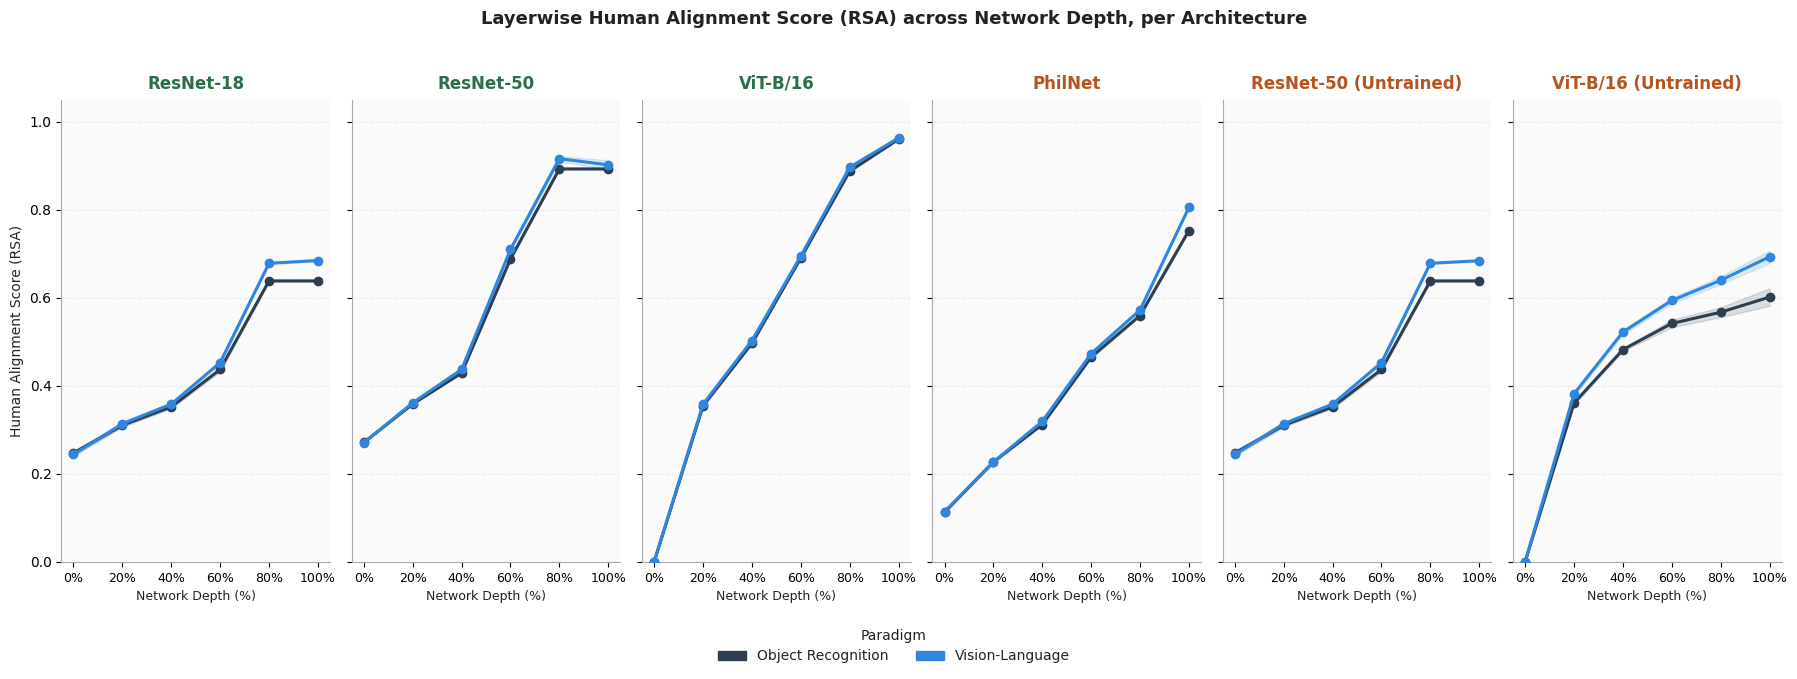

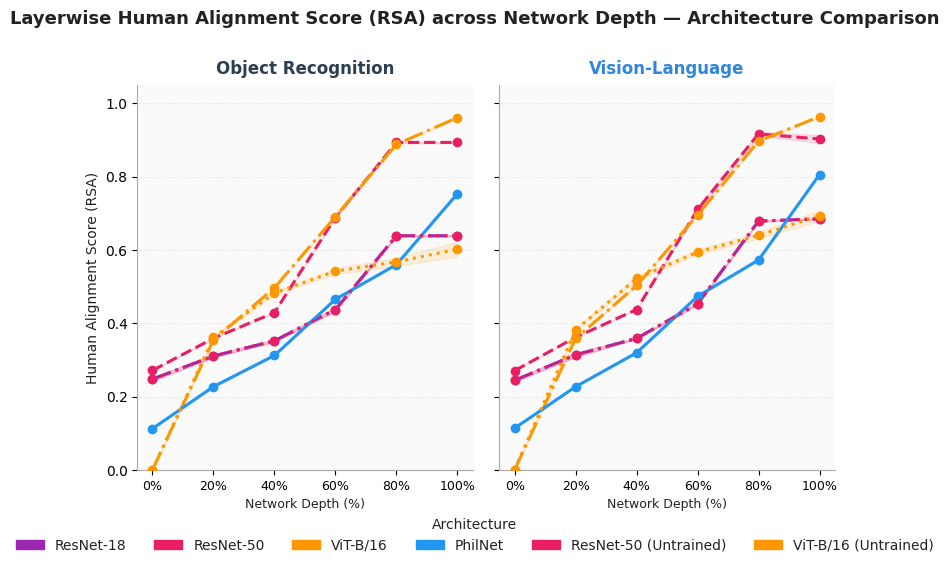

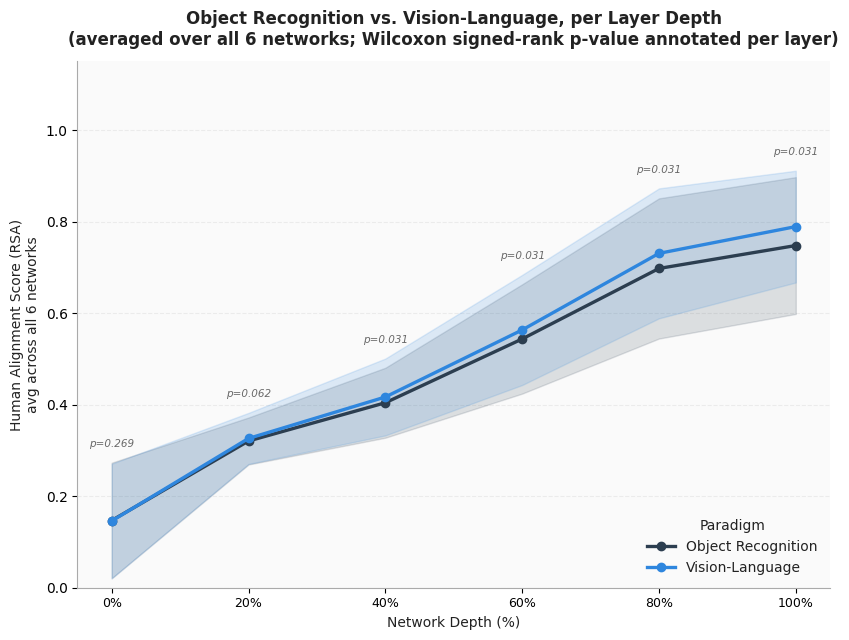

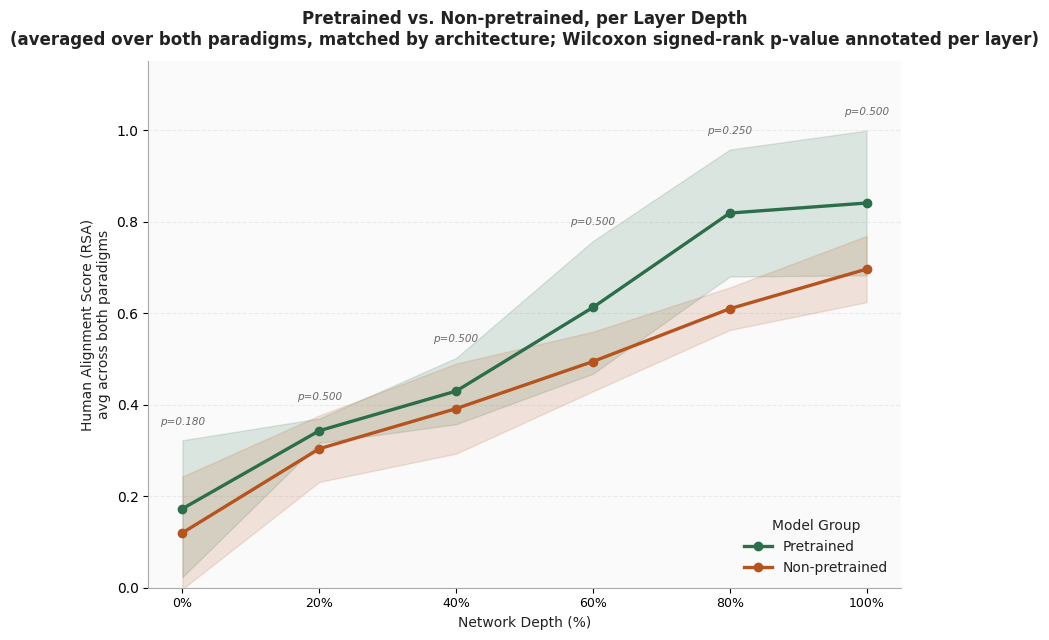

In [11]:
# CONFIG
# Same 6-model set as rsa_combined.py, grouped into pretrained / non-pretrained.

MODEL_STYLES = {
    "philnet":  "-",
    "resnet":   "--",
    "resnet18": "-.",
    "vit":      "-.",
}

MODEL_COLORS = {
    "philnet":  "#2196F3",
    "resnet":   "#E91E63",
    "resnet18": "#9C27B0",
    "vit":      "#FF9800",
}

# Off-the-shelf pretrained backbones (no in-house training) — produced by
# openclip_rn50_rsa_full.py, openclip_vitb16_rsa_full.py,
# imagenet_resnet50_rsa_full.py, imagenet_vitb16_rsa_full.py. No "untrained"
# counterpart exists for these, so they are excluded from the architecture-
# paired Pretrained-vs-Non-pretrained Wilcoxon comparisons, but are included
# as a third category in the per-layer Kruskal-Wallis omnibus test.

# Layer steps and depth on x axis
LAYER_STEPS = ["0pct", "20pct", "40pct", "60pct", "80pct", "100pct"]
LAYER_PCTS  = [0, 20, 40, 60, 80, 100]
LAYER_LABELS = ["0%", "20%", "40%", "60%", "80%", "100%"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#888888",
})


# Helper functions to dynamically support '_untrained' variants without KeyErrors
def get_model_label(model_name):
    base = model_name.replace("_untrained", "")
    label = MODEL_LABELS.get(base, base.upper())
    return f"{label} (Untrained)" if "_untrained" in model_name else label


def get_model_color(model_name):
    base = model_name.replace("_untrained", "")
    return MODEL_COLORS.get(base, "#757575")


def get_model_style(model_name):
    if "_untrained" in model_name:
        return ":"  # distinct dotted line for untrained models
    return MODEL_STYLES.get(model_name, "-")


def model_group(model_name):
    return "pretrained" if model_name in PRETRAINED_MODELS else "non_pretrained"


def style_axis(ax):
    ax.set_facecolor(BG_COLOR)
    ax.grid(axis="y", linestyle="--", alpha=0.5, color=GRID_COLOR, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#AAAAAA")


# DATA LOADING
def load_layerwise_json(model):
    # Resolve shared folder structure for untrained models AND resnet18
    # (resnet18 / resnet / resnet_untrained all live under the shared "resnet" folder)
    base_folder = (
        model
        .replace("_untrained", "")
        .replace("untrained", "")
        .replace("18", "")
    )
    paths = [
        f"./out/rsa_layerwise_{base_folder}/{model}_layerwise.json",
        f"./out/rsa_results_{base_folder}/{model}_layerwise.json",
        f"./out/rsa_results_{base_folder}/{base_folder}_layerwise.json",  # fallback
        f"{model}_layerwise.json",
    ]
    for p in paths:
        if os.path.exists(p):
            with open(p) as f:
                print(f"[OK] Found and loaded: {p}")
                return json.load(f)
    print(f"[SKIP] No layerwise JSON found for {model}")
    return None


def get_layers_for_paradigm(d, paradigm):
    """Extract layerwise means and stds for a given paradigm."""
    means, stds = [], []
    for l_name in LAYER_STEPS:
        match = None
        if d:
            for entry in d:
                if entry["paradigm"] == paradigm and entry["layer"] == l_name:
                    match = entry
                    break
        if match:
            means.append(match["mean_rsa"])
            stds.append(match["std_rsa"])
        else:
            means.append(np.nan)
            stds.append(0.0)
    return np.array(means), np.array(stds)


def load_off_the_shelf_layerwise_json(tag):
    """Loads the layerwise JSON produced by the corresponding *_rsa_full.py
    script for an off-the-shelf model (e.g. rsa_layerwise_resnet50_clip/
    resnet50_clip_layerwise.json)."""
    path = f"./out/rsa_layerwise_{tag}/{tag}_layerwise.json"
    if os.path.exists(path):
        with open(path) as f:
            print(f"[OK] Found and loaded: {path}")
            return json.load(f)
    print(f"[SKIP] No layerwise JSON found for off-the-shelf model {tag}")
    return None


# Load data safely
data = {m: load_layerwise_json(m) for m in models}
off_the_shelf_data = {cfg["tag"]: load_off_the_shelf_layerwise_json(cfg["tag"]) for cfg in OFF_THE_SHELF_MODELS}

# PLOT 1: Per model architecture
fig1, axes1 = plt.subplots(
    1, len(models), figsize=(3.7 * len(models), 6), sharey=True,
    gridspec_kw={"wspace": 0.08}
)
if len(models) == 1:
    axes1 = [axes1]
fig1.suptitle(
    "Layerwise Human Alignment Score (RSA) across Network Depth, per Architecture",
    fontsize=13, fontweight="bold", y=1.03
)
for idx, m in enumerate(models):
    ax = axes1[idx]
    d = data[m]
    for p in paradigms:
        means, stds = get_layers_for_paradigm(d, p)
        if not np.all(np.isnan(means)):
            ax.plot(LAYER_PCTS, means, color=colors[p], marker="o",
                    markersize=6, linewidth=2.2, label=paradigm_display[p], zorder=3)
            ax.fill_between(LAYER_PCTS, means - stds, means + stds,
                            color=colors[p], alpha=0.15, zorder=2)
        else:
            ax.text(50, 0.5, "Data not available", ha="center", va="center", alpha=0.5, fontsize=8)
    label = get_model_label(m)
    ax.set_title(label, fontsize=12, fontweight="bold", pad=8, color=GROUP_COLORS[model_group(m)])
    ax.set_xticks(LAYER_PCTS)
    ax.set_xticklabels(LAYER_LABELS, fontsize=9)
    ax.set_xlim(-5, 105)
    ax.set_ylim(0, 1.05)
    style_axis(ax)
    ax.set_xlabel("Network Depth (%)", fontsize=9)
    if idx == 0:
        ax.set_ylabel("Human Alignment Score (RSA)", fontsize=10)
legend1 = [mpatches.Patch(color=colors[p], label=paradigm_display[p]) for p in paradigms]
fig1.legend(handles=legend1, loc="lower center", ncol=len(paradigms), fontsize=10,
            frameon=False, bbox_to_anchor=(0.5, -0.08),
            title="Paradigm", title_fontsize=10)
plt.savefig("rsa_layerwise_by_model.png", dpi=150, bbox_inches="tight")
print("Saved: rsa_layerwise_by_model.png")

# PLOT 2: Per paradigm comparison
fig2, axes2 = plt.subplots(
    1, len(paradigms), figsize=(4.5 * len(paradigms), 5), sharey=True,
    gridspec_kw={"wspace": 0.08}
)
if len(paradigms) == 1:
    axes2 = [axes2]
fig2.suptitle(
    "Layerwise Human Alignment Score (RSA) across Network Depth — Architecture Comparison",
    fontsize=13, fontweight="bold", y=1.03
)
for p_idx, p in enumerate(paradigms):
    ax = axes2[p_idx]
    for m in models:
        means, stds = get_layers_for_paradigm(data[m], p)
        if not np.all(np.isnan(means)):
            ax.plot(LAYER_PCTS, means, color=get_model_color(m),
                    linestyle=get_model_style(m), marker="o",
                    markersize=6, linewidth=2.2,
                    label=get_model_label(m), zorder=3)
            ax.fill_between(LAYER_PCTS, means - stds, means + stds,
                            color=get_model_color(m), alpha=0.12, zorder=2)
    ax.set_title(paradigm_display[p], fontsize=12, fontweight="bold",
                 color=colors[p], pad=8)
    ax.set_xticks(LAYER_PCTS)
    ax.set_xticklabels(LAYER_LABELS, fontsize=9)
    ax.set_xlim(-5, 105)
    ax.set_ylim(0, 1.05)
    style_axis(ax)
    ax.set_xlabel("Network Depth (%)", fontsize=9)
    if p_idx == 0:
        ax.set_ylabel("Human Alignment Score (RSA)", fontsize=10)
legend2 = [mpatches.Patch(color=get_model_color(m), label=get_model_label(m)) for m in models]
fig2.legend(handles=legend2, loc="lower center", ncol=len(models), fontsize=10,
            frameon=False, bbox_to_anchor=(0.5, -0.08),
            title="Architecture", title_fontsize=10)
plt.savefig("rsa_layerwise_by_paradigm.png", dpi=150, bbox_inches="tight")
print("Saved: rsa_layerwise_by_paradigm.png")

# STATISTICAL TESTING HELPER
#
# Following RSA methodology guidance (Nili et al., 2014), comparisons between
# RSA/alignment scores default to a non-parametric Wilcoxon signed-rank test
# rather than the paired Student's t-test, since RSA correlation scores are
# frequently non-normal and outlier-sensitive. Wilcoxon is reported as the
# PRIMARY test; paired t-test, exact sign-permutation, and Cohen's d are kept
# as secondary/robustness references.

def run_paired_tests(scores_a, scores_b, verbose_prefix=""):
    diffs = np.array(scores_a) - np.array(scores_b)
    result = {"t_p": np.nan, "w_p": np.nan, "perm_p": np.nan, "d": np.nan}

    if np.any(np.isnan(diffs)):
        print(f"{verbose_prefix}Cannot run tests: missing data.")
        return result

    try:
        w_stat, w_p = stats.wilcoxon(scores_a, scores_b)
        print(f"{verbose_prefix}[PRIMARY]  Wilcoxon signed-rank:  W = {w_stat:.4f}, p = {w_p:.4f}")
        result["w_p"] = w_p
    except ValueError as e:
        print(f"{verbose_prefix}[PRIMARY]  Wilcoxon signed-rank:  not computable ({e})")

    t_stat, t_p = stats.ttest_rel(scores_a, scores_b)
    print(f"{verbose_prefix}[secondary] Paired t-test:          t = {t_stat:.4f}, p = {t_p:.4f}")
    result["t_p"] = t_p

    signs = [1, -1]
    perm_means = [np.mean(np.array(combo) * np.abs(diffs)) for combo in product(signs, repeat=len(diffs))]
    observed = np.mean(diffs)
    perm_p = np.mean(np.abs(perm_means) >= np.abs(observed))
    print(f"{verbose_prefix}[secondary] Sign-permutation test:   observed diff = {observed:.4f}, p = {perm_p:.4f}")
    result["perm_p"] = perm_p

    d_eff = observed / np.std(diffs, ddof=1) if np.std(diffs, ddof=1) > 0 else np.nan
    print(f"{verbose_prefix}[secondary] Cohen's d (paired):      d = {d_eff:.4f}")
    result["d"] = d_eff

    return result


# PARADIGM AVERAGES PER LAYER: Object Recognition vs. Vision-Language
# For each layer step, average across the 6 models -> one score per model per
# paradigm per layer, paired across the 6 models at that layer.
model_layer_scores = {m: {p: get_layers_for_paradigm(data[m], p)[0] for p in paradigms} for m in models}

layer_paradigm_scores = {
    p: [[model_layer_scores[m][p][l_idx] for m in models] for l_idx in range(len(LAYER_STEPS))]
    for p in paradigms
}
layer_paradigm_avg = {p: [float(np.nanmean(scores)) for scores in layer_paradigm_scores[p]] for p in paradigms}
layer_paradigm_std = {p: [float(np.nanstd(scores, ddof=1)) for scores in layer_paradigm_scores[p]] for p in paradigms}

print("\n=== Paradigm averages per layer (Human Alignment Score, averaged over all 6 models) ===")
for p in paradigms:
    print(f"{paradigm_display[p]:20s} " +
          ", ".join(f"{lbl}={avg:.3f}" for lbl, avg in zip(LAYER_LABELS, layer_paradigm_avg[p])))

# STATISTICAL TEST PER LAYER: Object Recognition vs. Vision-Language
# n = number of models (6), paired within model, run separately at each layer step.
# PRIMARY: Wilcoxon signed-rank. Secondary: paired t-test, sign-permutation, Cohen's d.
layer_test_results = []  # list of dicts, one per layer step

print(f"\n=== Statistical comparison per layer: {names_paradigms[0]} vs. {names_paradigms[1]} "
      f"(n={len(models)}, paired) ===")

for l_idx, l_label in enumerate(LAYER_LABELS):
    scores_p0 = layer_paradigm_scores[paradigms[0]][l_idx]
    scores_p1 = layer_paradigm_scores[paradigms[1]][l_idx]
    print(f"\n-- Layer depth {l_label} --")
    result = run_paired_tests(scores_p0, scores_p1)
    result["layer"] = l_label
    layer_test_results.append(result)

print(f"\nNote: n={len(models)} paired observations per layer (one per model). Per RSA "
      "methodology guidance (Nili et al., 2014), the Wilcoxon signed-rank result is the "
      "primary reference; other tests and the effect size are supplementary.")

# KRUSKAL-WALLIS TEST PER LAYER (non-parametric ANOVA equivalent) — tests
# whether alignment scores differ across all model groups at that layer depth,
# pooling both paradigm observations per in-house model as the group's samples,
# plus the 4 off-the-shelf models (OpenCLIP RN50/ViT-B16, ImageNet RN50/ViT-B16)
# as additional single-observation groups (they only have one paradigm each, so
# they can't be architecture-paired with an "untrained" counterpart — but they
# are valid extra groups for this omnibus comparison).
# NOTE: n=2 observations per in-house group (one per paradigm) and n=1 per
# off-the-shelf group severely limits power; included as an omnibus,
# descriptive check rather than a strong inferential claim.

n_total_kw_models = len(models) + len(OFF_THE_SHELF_MODELS)
print(f"\n{'='*70}\nKRUSKAL-WALLIS TEST per layer (non-parametric ANOVA equivalent, "
      f"across {n_total_kw_models} models)\n{'='*70}")

# Pre-extract off-the-shelf layerwise means per model, for its single paradigm
off_the_shelf_layer_means = {}
for cfg in OFF_THE_SHELF_MODELS:
    means, _ = get_layers_for_paradigm(off_the_shelf_data[cfg["tag"]], cfg["paradigm"])
    off_the_shelf_layer_means[cfg["tag"]] = means

kw_results_by_layer = {}
for l_idx, l_label in enumerate(LAYER_LABELS):
    kw_groups = []
    for m in models:
        vals = [model_layer_scores[m][p][l_idx] for p in paradigms
                if not np.isnan(model_layer_scores[m][p][l_idx])]
        if vals:
            kw_groups.append(vals)
    for cfg in OFF_THE_SHELF_MODELS:
        val = off_the_shelf_layer_means[cfg["tag"]][l_idx]
        if not np.isnan(val):
            kw_groups.append([float(val)])

    if len(kw_groups) >= 2 and all(len(g) > 0 for g in kw_groups):
        try:
            h_stat, kw_p = stats.kruskal(*kw_groups)
            kw_results_by_layer[l_label] = kw_p
            print(f"Layer {l_label:>5}: H = {h_stat:.4f}, p = {kw_p:.4f}  (n groups = {len(kw_groups)})")
        except ValueError as e:
            kw_results_by_layer[l_label] = np.nan
            print(f"Layer {l_label:>5}: not computable ({e})")
    else:
        kw_results_by_layer[l_label] = np.nan
        print(f"Layer {l_label:>5}: insufficient data")

# FIGURE: paradigm comparison per layer (line plot with SD error band across models)

fig3, ax3 = plt.subplots(figsize=(8.5, 6.5))
style_axis(ax3)

for p in paradigms:
    means = np.array(layer_paradigm_avg[p])
    stds = np.array(layer_paradigm_std[p])
    ax3.plot(LAYER_PCTS, means, color=colors[p], marker="o", markersize=6,
              linewidth=2.4, label=paradigm_display[p], zorder=3)
    ax3.fill_between(LAYER_PCTS, means - stds, means + stds,
                       color=colors[p], alpha=0.15, zorder=2)

# Annotate primary (Wilcoxon) p-value at each layer step
for l_idx, l_pct in enumerate(LAYER_PCTS):
    p_val = layer_test_results[l_idx]["w_p"]
    if not np.isnan(p_val):
        y_top = max(layer_paradigm_avg[p][l_idx] + layer_paradigm_std[p][l_idx] for p in paradigms)
        ax3.text(l_pct, y_top + 0.03, f"p={p_val:.3f}", ha="center", va="bottom",
                  fontsize=7.5, style="italic", color="dimgray")

ax3.set_xticks(LAYER_PCTS)
ax3.set_xticklabels(LAYER_LABELS, fontsize=9)
ax3.set_xlim(-5, 105)
ax3.set_ylim(0, 1.15)
ax3.set_xlabel("Network Depth (%)", fontsize=10)
ax3.set_ylabel("Human Alignment Score (RSA)\navg across all 6 networks", fontsize=10)
ax3.set_title("Object Recognition vs. Vision-Language, per Layer Depth\n"
              "(averaged over all 6 networks; Wilcoxon signed-rank p-value annotated per layer)",
              fontsize=12, fontweight="bold", pad=12)
ax3.legend(loc="lower right", fontsize=10, frameon=False, title="Paradigm", title_fontsize=10)

plt.tight_layout()
plt.savefig("rsa_layerwise_paradigm_comparison.png", dpi=150, bbox_inches="tight")
print("\nSaved: rsa_layerwise_paradigm_comparison.png")


# PRETRAINED vs. NON-PRETRAINED, PER LAYER DEPTH
# For each layer step, average each model's alignment score across both
# paradigms, then compare the pretrained group (resnet18, resnet, vit) against
# the non-pretrained group (philnet, resnet_untrained, vit_untrained), paired
# by matched architecture, at every layer depth.

def model_layer_avg_over_paradigms(m, l_idx):
    vals = [model_layer_scores[m][p][l_idx] for p in paradigms]
    return float(np.nanmean(vals))


pretrained_layer_scores = [[model_layer_avg_over_paradigms(m, l_idx) for m in PRETRAINED_MODELS]
                            for l_idx in range(len(LAYER_STEPS))]
non_pretrained_layer_scores = [[model_layer_avg_over_paradigms(m, l_idx) for m in NON_PRETRAINED_MODELS]
                                for l_idx in range(len(LAYER_STEPS))]

pretrained_layer_avg = [float(np.nanmean(s)) for s in pretrained_layer_scores]
pretrained_layer_std = [float(np.nanstd(s, ddof=1)) for s in pretrained_layer_scores]
non_pretrained_layer_avg = [float(np.nanmean(s)) for s in non_pretrained_layer_scores]
non_pretrained_layer_std = [float(np.nanstd(s, ddof=1)) for s in non_pretrained_layer_scores]

print(f"\n=== Statistical comparison per layer: Pretrained vs. Non-pretrained "
      f"(n={len(PRETRAINED_MODELS)}, paired by matched architecture) ===")

pretrained_layer_test_results = []
for l_idx, l_label in enumerate(LAYER_LABELS):
    print(f"\n-- Layer depth {l_label} --")
    result = run_paired_tests(pretrained_layer_scores[l_idx], non_pretrained_layer_scores[l_idx])
    result["layer"] = l_label
    pretrained_layer_test_results.append(result)

print(f"\nNote: n={len(PRETRAINED_MODELS)} paired observations per layer (one per matched "
      "architecture pair). Small n limits power for all tests here; Wilcoxon remains the "
      "primary reference per RSA methodology guidance.")

# FIGURE: pretrained vs. non-pretrained per layer (line plot with SD error band)

fig4, ax4 = plt.subplots(figsize=(8.5, 6.5))
style_axis(ax4)

group_data = {
    "pretrained": (pretrained_layer_avg, pretrained_layer_std),
    "non_pretrained": (non_pretrained_layer_avg, non_pretrained_layer_std),
}
for group_key, (means_list, stds_list) in group_data.items():
    means = np.array(means_list)
    stds = np.array(stds_list)
    ax4.plot(LAYER_PCTS, means, color=GROUP_COLORS[group_key], marker="o", markersize=6,
              linewidth=2.4, label=GROUP_LABELS[group_key], zorder=3)
    ax4.fill_between(LAYER_PCTS, means - stds, means + stds,
                       color=GROUP_COLORS[group_key], alpha=0.15, zorder=2)

for l_idx, l_pct in enumerate(LAYER_PCTS):
    p_val = pretrained_layer_test_results[l_idx]["w_p"]
    if not np.isnan(p_val):
        y_top = max(pretrained_layer_avg[l_idx] + pretrained_layer_std[l_idx],
                    non_pretrained_layer_avg[l_idx] + non_pretrained_layer_std[l_idx])
        ax4.text(l_pct, y_top + 0.03, f"p={p_val:.3f}", ha="center", va="bottom",
                  fontsize=7.5, style="italic", color="dimgray")

ax4.set_xticks(LAYER_PCTS)
ax4.set_xticklabels(LAYER_LABELS, fontsize=9)
ax4.set_xlim(-5, 105)
ax4.set_ylim(0, 1.15)
ax4.set_xlabel("Network Depth (%)", fontsize=10)
ax4.set_ylabel("Human Alignment Score (RSA)\navg across both paradigms", fontsize=10)
ax4.set_title("Pretrained vs. Non-pretrained, per Layer Depth\n"
              "(averaged over both paradigms, matched by architecture; "
              "Wilcoxon signed-rank p-value annotated per layer)",
              fontsize=12, fontweight="bold", pad=12)
ax4.legend(loc="lower right", fontsize=10, frameon=False, title="Model Group", title_fontsize=10)

plt.tight_layout()
plt.savefig("rsa_layerwise_pretrained_vs_nonpretrained.png", dpi=150, bbox_inches="tight")
print("Saved: rsa_layerwise_pretrained_vs_nonpretrained.png")

plt.show()

[OK] Found and loaded: ./out/rsa_results_resnet/rsa_entropy_resnet18.json
[OK] Found and loaded: ./out/rsa_results_resnet/rsa_entropy_resnet.json
[OK] Found and loaded: ./out/rsa_results_vit/rsa_entropy_vit.json
[OK] Found and loaded: ./out/rsa_results_philnet/rsa_entropy_philnet.json
[OK] Found and loaded: ./out/rsa_results_resnet/rsa_entropy_resnet_untrained.json
[OK] Found and loaded: ./out/rsa_results_vit/rsa_entropy_vit_untrained.json
[OK] Found and loaded: ./out/rsa_results_resnet50_clip/rsa_entropy_resnet50_clip.json
[OK] Found and loaded: ./out/rsa_results_vit_b16_clip/rsa_entropy_vit_b16_clip.json
[OK] Found and loaded: ./out/rsa_results_resnet50_imagenet/rsa_entropy_resnet50_imagenet.json
[OK] Found and loaded: ./out/rsa_results_vit_b16_imagenet/rsa_entropy_vit_b16_imagenet.json
Saved: rsa_entropy_by_model.png
Saved: rsa_entropy_by_paradigm.png
Saved: rsa_entropy_grid.png

=== Paradigm averages per entropy quartile (Human Alignment Score, averaged over all 6 models) ===
Objec

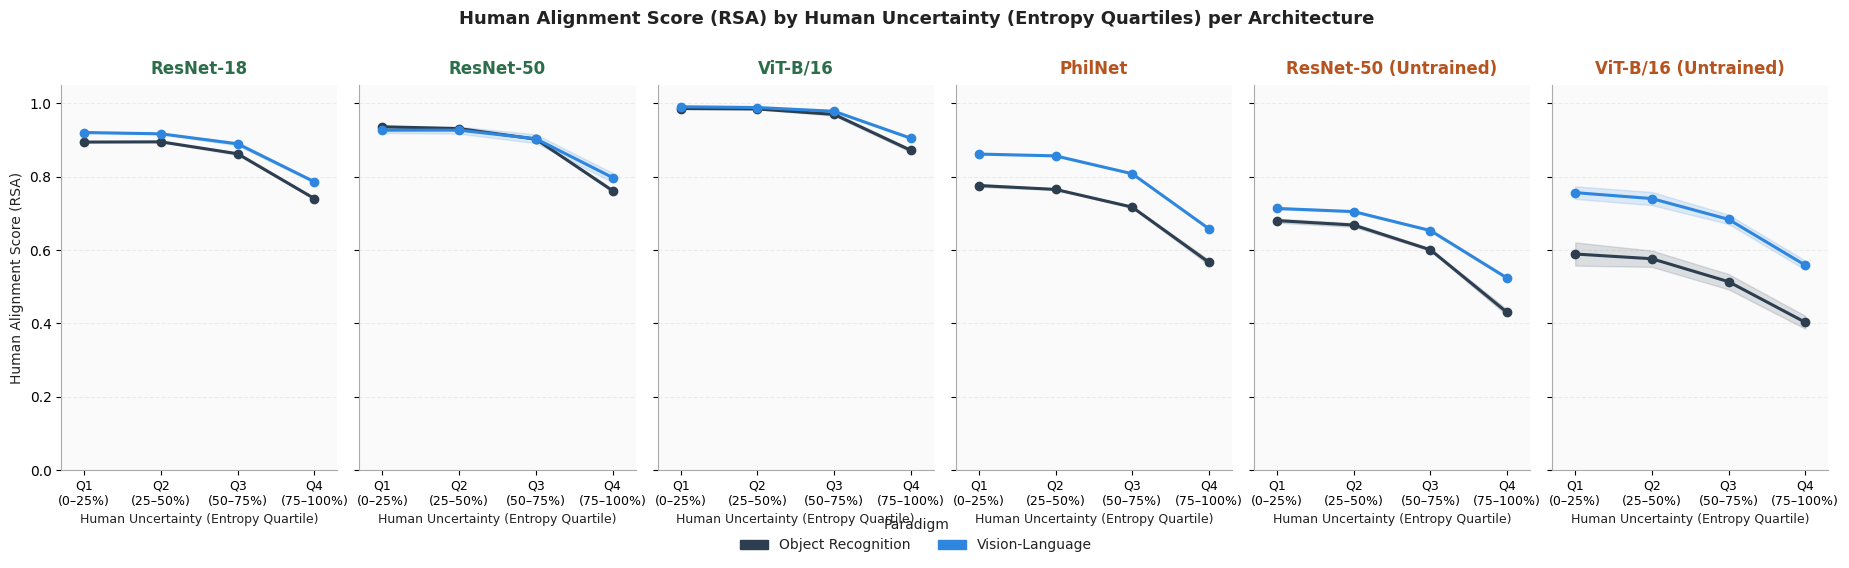

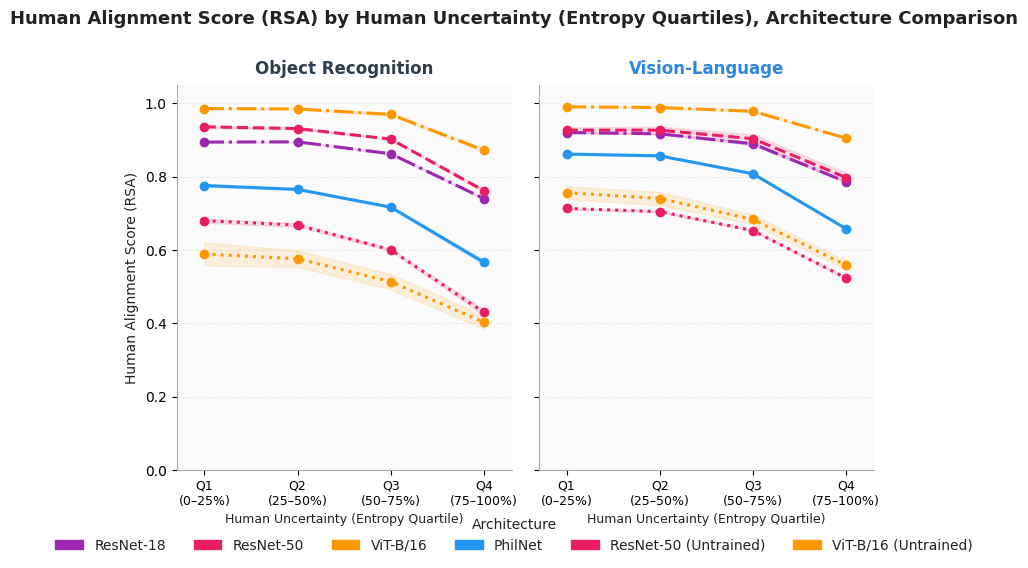

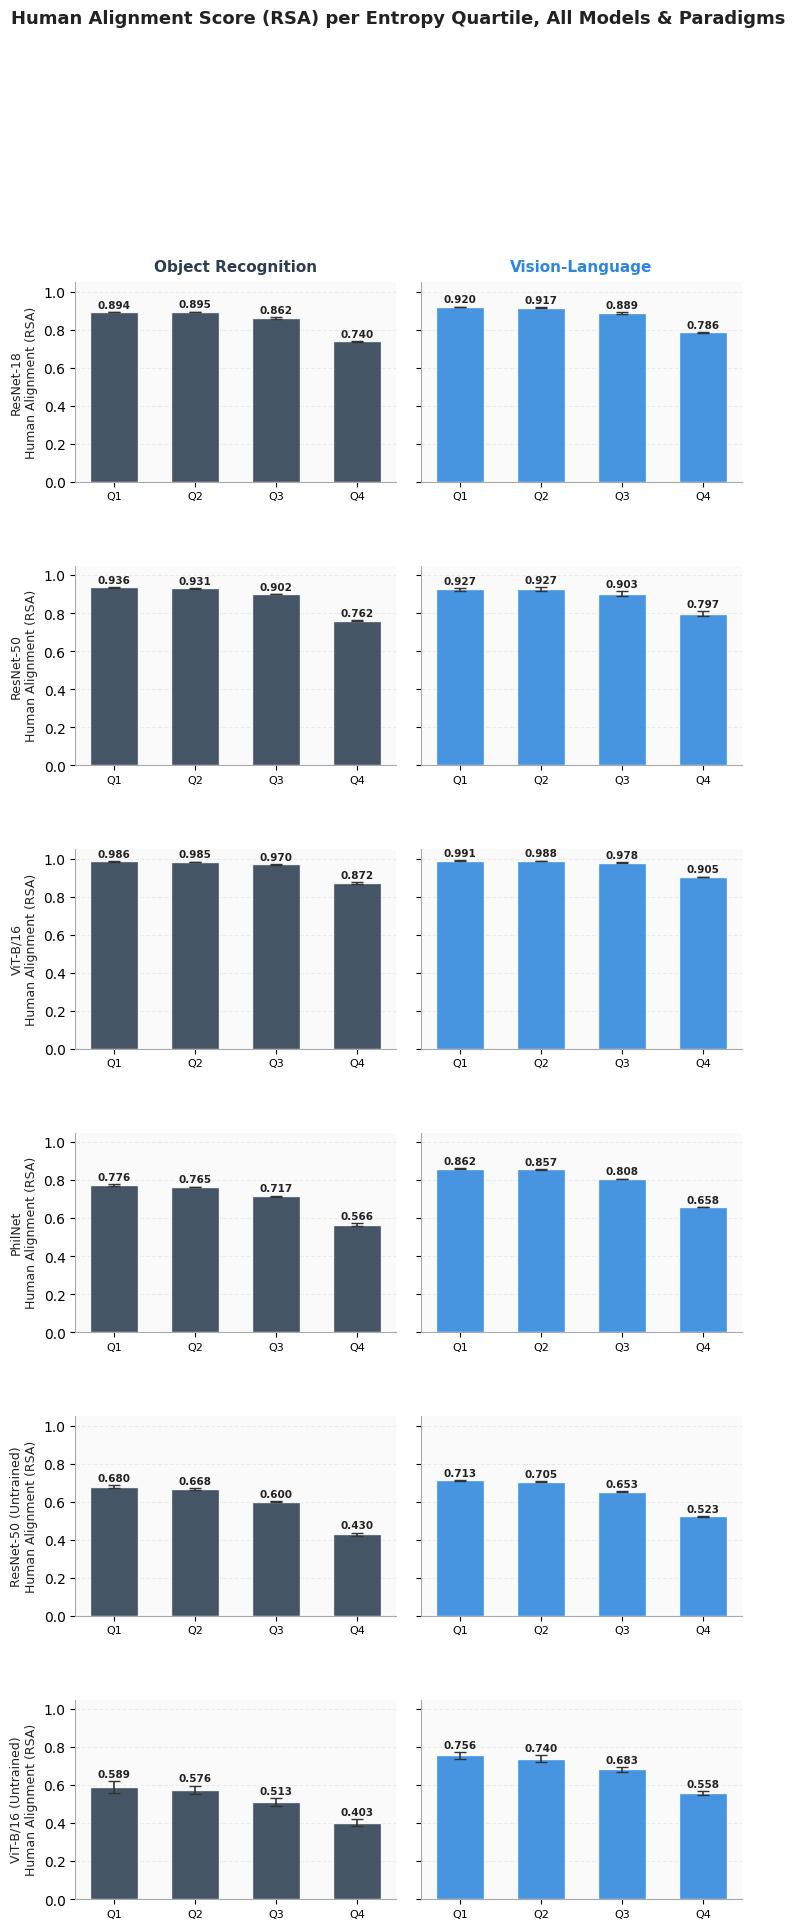

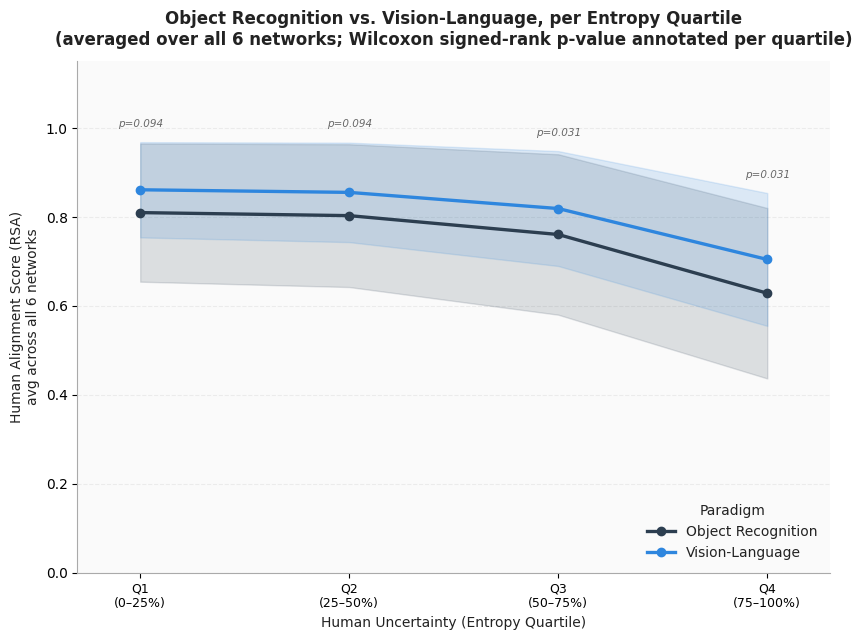

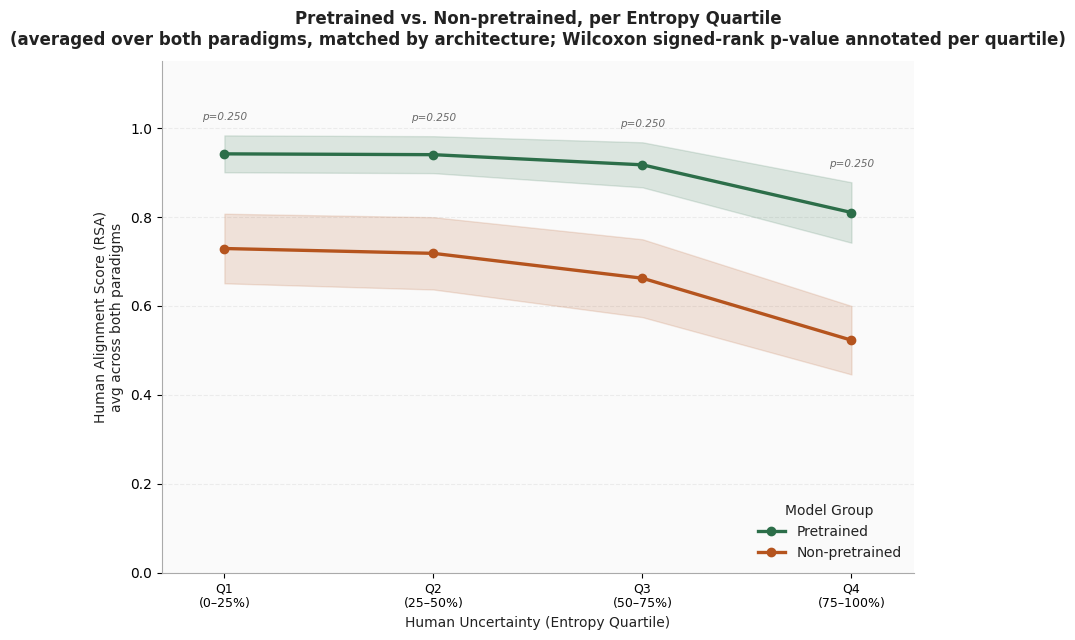

In [12]:
# Off-the-shelf pretrained backbones (no in-house training) — produced by
# openclip_rn50_rsa_full.py, openclip_vitb16_rsa_full.py,
# imagenet_resnet50_rsa_full.py, imagenet_vitb16_rsa_full.py. No "untrained"
# counterpart exists for these, so they are excluded from the architecture-
# paired Pretrained-vs-Non-pretrained Wilcoxon comparisons, but are included
# as a third category in the per-quartile Kruskal-Wallis omnibus test.

# Entropy bin keys
BIN_KEYS   = [
    "entropy_Q1_0-25pct",
    "entropy_Q2_25-50pct",
    "entropy_Q3_50-75pct",
    "entropy_Q4_75-100pct",
]
BIN_LABELS = ["Q1\n(0–25%)", "Q2\n(25–50%)", "Q3\n(50–75%)", "Q4\n(75–100%)"]
x_bins = np.arange(len(BIN_KEYS))

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#888888",
})


# Helper functions to dynamically support '_untrained' variants safely
def get_model_label(model_name):
    base = model_name.replace("_untrained", "")
    label = MODEL_LABELS.get(base, base.upper())
    return f"{label} (Untrained)" if "_untrained" in model_name else label


def get_model_color(model_name):
    base = model_name.replace("_untrained", "")
    return MODEL_COLORS.get(base, "#757575")


def get_model_style(model_name):
    if "_untrained" in model_name:
        return ":"  # distinct dotted line style for untrained architecture
    return MODEL_STYLES.get(model_name, "-")


def model_group(model_name):
    return "pretrained" if model_name in PRETRAINED_MODELS else "non_pretrained"


def style_axis(ax):
    ax.set_facecolor(BG_COLOR)
    ax.grid(axis="y", linestyle="--", alpha=0.5, color=GRID_COLOR, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#AAAAAA")


# DATA LOADING
def load_entropy_json(model):
    # Resolve shared folder structure for untrained models AND resnet18
    # (resnet18 / resnet / resnet_untrained all live under the shared "resnet" folder)
    base_folder = (
        model
        .replace("_untrained", "")
        .replace("untrained", "")
        .replace("18", "")
    )
    paths = [
        f"./out/rsa_entropy_results_{base_folder}/rsa_entropy_{model}.json",
        f"./out/rsa_results_{base_folder}/rsa_entropy_{model}.json",
        f"./out/rsa_results_{base_folder}/rsa_entropy_{base_folder}.json",  # fallback
        f"rsa_entropy_{model}.json",
    ]
    for p in paths:
        if os.path.exists(p):
            with open(p) as f:
                print(f"[OK] Found and loaded: {p}")
                return json.load(f)
    print(f"[SKIP] No JSON found for {model}")
    return None


def get_bins_for_paradigm(d, paradigm):
    """Returns means and stds for all entropy bins of a given paradigm."""
    means, stds = [], []
    for bk in BIN_KEYS:
        if d and bk in d and paradigm in d[bk]:
            means.append(d[bk][paradigm]["mean"])
            stds.append(d[bk][paradigm]["std"])
        else:
            means.append(np.nan)
            stds.append(0.0)
    return np.array(means), np.array(stds)


def load_off_the_shelf_entropy_json(tag):
    """Loads the entropy-quartile JSON produced by the corresponding
    *_rsa_full.py script for an off-the-shelf model
    (e.g. rsa_results_resnet50_clip/rsa_entropy_resnet50_clip.json)."""
    path = f"./out/rsa_results_{tag}/rsa_entropy_{tag}.json"
    if os.path.exists(path):
        with open(path) as f:
            print(f"[OK] Found and loaded: {path}")
            return json.load(f)
    print(f"[SKIP] No entropy JSON found for off-the-shelf model {tag}")
    return None


def get_bins_for_off_the_shelf(d, paradigm):
    """Same shape as get_bins_for_paradigm but for the off-the-shelf JSON layout
    (rsa_entropy_{tag}.json uses the same bin-key / paradigm-key structure)."""
    return get_bins_for_paradigm(d, paradigm)


# Load data safely
data = {m: load_entropy_json(m) for m in models}
off_the_shelf_data = {cfg["tag"]: load_off_the_shelf_entropy_json(cfg["tag"]) for cfg in OFF_THE_SHELF_MODELS}

# PLOT 1: Per model
fig1, axes1 = plt.subplots(
    1, len(models), figsize=(3.8 * len(models), 5), sharey=True,
    gridspec_kw={"wspace": 0.08}
)
if len(models) == 1:
    axes1 = [axes1]
fig1.suptitle(
    "Human Alignment Score (RSA) by Human Uncertainty (Entropy Quartiles) per Architecture",
    fontsize=13, fontweight="bold", y=1.03
)
for idx, m in enumerate(models):
    ax = axes1[idx]
    d = data[m]
    for p in paradigms:
        means, stds = get_bins_for_paradigm(d, p)
        if not np.all(np.isnan(means)):
            ax.plot(x_bins, means, color=colors[p], marker="o",
                    markersize=6, linewidth=2.2, label=paradigm_display[p], zorder=3)
            ax.fill_between(x_bins, means - stds, means + stds,
                            color=colors[p], alpha=0.15, zorder=2)
        else:
            ax.text(1.5, 0.5, "Data not available", ha="center", va="center", alpha=0.5, fontsize=8)
    ax.set_title(get_model_label(m), fontsize=12, fontweight="bold", pad=8,
                 color=GROUP_COLORS[model_group(m)])
    ax.set_xticks(x_bins)
    ax.set_xticklabels(BIN_LABELS, fontsize=9)
    ax.set_xlim(-0.3, len(BIN_KEYS) - 0.7)
    ax.set_ylim(0, 1.05)
    style_axis(ax)
    ax.set_xlabel("Human Uncertainty (Entropy Quartile)", fontsize=9)
    if idx == 0:
        ax.set_ylabel("Human Alignment Score (RSA)", fontsize=10)
legend1 = [mpatches.Patch(color=colors[p], label=paradigm_display[p]) for p in paradigms]
fig1.legend(handles=legend1, loc="lower center", ncol=len(paradigms), fontsize=10,
            frameon=False, bbox_to_anchor=(0.5, -0.08),
            title="Paradigm", title_fontsize=10)
plt.savefig("rsa_entropy_by_model.png", dpi=150, bbox_inches="tight")
print("Saved: rsa_entropy_by_model.png")

# PLOT 2: Per paradigm
fig2, axes2 = plt.subplots(
    1, len(paradigms), figsize=(4.5 * len(paradigms), 5), sharey=True,
    gridspec_kw={"wspace": 0.08}
)
if len(paradigms) == 1:
    axes2 = [axes2]
fig2.suptitle(
    "Human Alignment Score (RSA) by Human Uncertainty (Entropy Quartiles), Architecture Comparison",
    fontsize=13, fontweight="bold", y=1.03
)
for p_idx, p in enumerate(paradigms):
    ax = axes2[p_idx]
    for m in models:
        means, stds = get_bins_for_paradigm(data[m], p)
        if not np.all(np.isnan(means)):
            ax.plot(x_bins, means, color=get_model_color(m),
                    linestyle=get_model_style(m), marker="o",
                    markersize=6, linewidth=2.2,
                    label=get_model_label(m), zorder=3)
            ax.fill_between(x_bins, means - stds, means + stds,
                            color=get_model_color(m), alpha=0.12, zorder=2)
    ax.set_title(paradigm_display[p], fontsize=12, fontweight="bold",
                 color=colors[p], pad=8)
    ax.set_xticks(x_bins)
    ax.set_xticklabels(BIN_LABELS, fontsize=9)
    ax.set_xlim(-0.3, len(BIN_KEYS) - 0.7)
    ax.set_ylim(0, 1.05)
    style_axis(ax)
    ax.set_xlabel("Human Uncertainty (Entropy Quartile)", fontsize=9)
    if p_idx == 0:
        ax.set_ylabel("Human Alignment Score (RSA)", fontsize=10)
legend2 = [mpatches.Patch(color=get_model_color(m), label=get_model_label(m)) for m in models]
fig2.legend(handles=legend2, loc="lower center", ncol=len(models), fontsize=10,
            frameon=False, bbox_to_anchor=(0.5, -0.08),
            title="Architecture", title_fontsize=10)
plt.savefig("rsa_entropy_by_paradigm.png", dpi=150, bbox_inches="tight")
print("Saved: rsa_entropy_by_paradigm.png")

# PLOT 3: Combined grid matrix (dynamically sized)
WIDTH = 0.6
fig3, axes3 = plt.subplots(
    len(models), len(paradigms), figsize=(4.3 * len(paradigms), 3.5 * len(models)), sharey=True,
    gridspec_kw={"hspace": 0.42, "wspace": 0.08}
)
if len(models) == 1 and len(paradigms) == 1:
    axes3 = np.array([[axes3]])
elif len(models) == 1:
    axes3 = np.expand_dims(axes3, axis=0)
elif len(paradigms) == 1:
    axes3 = np.expand_dims(axes3, axis=1)
fig3.suptitle(
    "Human Alignment Score (RSA) per Entropy Quartile, All Models & Paradigms",
    fontsize=13, fontweight="bold", y=1.01
)
for m_idx, m in enumerate(models):
    for p_idx, p in enumerate(paradigms):
        ax = axes3[m_idx, p_idx]
        d = data[m]
        means, stds = get_bins_for_paradigm(d, p)
        style_axis(ax)
        if not np.all(np.isnan(means)):
            bars = ax.bar(x_bins, means, width=WIDTH,
                          color=colors[p], alpha=0.88,
                          edgecolor="white", linewidth=1.0, zorder=3)
            ax.errorbar(x_bins, means, yerr=stds, fmt="none",
                        ecolor="#333333", elinewidth=1.2, capsize=4, zorder=4)
            for bar, mean, std in zip(bars, means, stds):
                if not np.isnan(mean):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            mean + std + 0.01,
                            f"{mean:.3f}", ha="center", va="bottom",
                            fontsize=7.5, fontweight="bold")
        else:
            ax.text(1.5, 0.5, "No Data", ha="center", va="center", alpha=0.4, fontsize=8)
        ax.set_xticks(x_bins)
        ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4"], fontsize=8)
        ax.set_ylim(0, 1.05)
        if m_idx == 0:
            ax.set_title(paradigm_display[p], fontsize=11, fontweight="bold",
                         color=colors[p], pad=8)
        if p_idx == 0:
            ax.set_ylabel(f"{get_model_label(m)}\nHuman Alignment (RSA)", fontsize=9)
plt.savefig("rsa_entropy_grid.png", dpi=150, bbox_inches="tight")
print("Saved: rsa_entropy_grid.png")

# STATISTICAL TESTING HELPER
#
# Following RSA methodology guidance (Nili et al., 2014), comparisons between
# RSA/alignment scores default to a non-parametric Wilcoxon signed-rank test
# rather than the paired Student's t-test, since RSA correlation scores are
# frequently non-normal and outlier-sensitive. Wilcoxon is reported as the
# PRIMARY test; paired t-test, exact sign-permutation, and Cohen's d are kept
# as secondary/robustness references.

def run_paired_tests(scores_a, scores_b, verbose_prefix=""):
    diffs = np.array(scores_a) - np.array(scores_b)
    result = {"t_p": np.nan, "w_p": np.nan, "perm_p": np.nan, "d": np.nan}

    if np.any(np.isnan(diffs)):
        print(f"{verbose_prefix}Cannot run tests: missing data.")
        return result

    try:
        w_stat, w_p = stats.wilcoxon(scores_a, scores_b)
        print(f"{verbose_prefix}[PRIMARY]  Wilcoxon signed-rank:  W = {w_stat:.4f}, p = {w_p:.4f}")
        result["w_p"] = w_p
    except ValueError as e:
        print(f"{verbose_prefix}[PRIMARY]  Wilcoxon signed-rank:  not computable ({e})")

    t_stat, t_p = stats.ttest_rel(scores_a, scores_b)
    print(f"{verbose_prefix}[secondary] Paired t-test:          t = {t_stat:.4f}, p = {t_p:.4f}")
    result["t_p"] = t_p

    signs = [1, -1]
    perm_means = [np.mean(np.array(combo) * np.abs(diffs)) for combo in product(signs, repeat=len(diffs))]
    observed = np.mean(diffs)
    perm_p = np.mean(np.abs(perm_means) >= np.abs(observed))
    print(f"{verbose_prefix}[secondary] Sign-permutation test:   observed diff = {observed:.4f}, p = {perm_p:.4f}")
    result["perm_p"] = perm_p

    d_eff = observed / np.std(diffs, ddof=1) if np.std(diffs, ddof=1) > 0 else np.nan
    print(f"{verbose_prefix}[secondary] Cohen's d (paired):      d = {d_eff:.4f}")
    result["d"] = d_eff

    return result


# PARADIGM AVERAGES PER ENTROPY QUARTILE: Object Recognition vs. Vision-Language
# For each quartile, average across the 6 models -> one score per model per
# paradigm per quartile, paired across the 6 models at that quartile.
model_bin_scores = {m: {p: get_bins_for_paradigm(data[m], p)[0] for p in paradigms} for m in models}

bin_paradigm_scores = {
    p: [[model_bin_scores[m][p][b_idx] for m in models] for b_idx in range(len(BIN_KEYS))]
    for p in paradigms
}
bin_paradigm_avg = {p: [float(np.nanmean(scores)) for scores in bin_paradigm_scores[p]] for p in paradigms}
bin_paradigm_std = {p: [float(np.nanstd(scores, ddof=1)) for scores in bin_paradigm_scores[p]] for p in paradigms}

print("\n=== Paradigm averages per entropy quartile (Human Alignment Score, averaged over all 6 models) ===")
for p in paradigms:
    print(f"{paradigm_display[p]:20s} " +
          ", ".join(f"{lbl.replace(chr(10), ' ')}={avg:.3f}"
                    for lbl, avg in zip(BIN_LABELS, bin_paradigm_avg[p])))

# STATISTICAL TEST PER QUARTILE: Object Recognition vs. Vision-Language
# n = number of models (6), paired within model, run separately at each quartile.
# PRIMARY: Wilcoxon signed-rank. Secondary: paired t-test, sign-permutation, Cohen's d.
bin_test_results = []
print(f"\n=== Statistical comparison per quartile: {names_paradigms[0]} vs. {names_paradigms[1]} "
      f"(n={len(models)}, paired) ===")

for b_idx, b_label in enumerate(BIN_LABELS):
    scores_p0 = bin_paradigm_scores[paradigms[0]][b_idx]
    scores_p1 = bin_paradigm_scores[paradigms[1]][b_idx]
    print(f"\n-- {b_label.replace(chr(10), ' ')} --")
    result = run_paired_tests(scores_p0, scores_p1)
    result["bin"] = b_label
    bin_test_results.append(result)

print(f"\nNote: n={len(models)} paired observations per quartile (one per model). Per RSA "
      "methodology guidance (Nili et al., 2014), the Wilcoxon signed-rank result is the "
      "primary reference; other tests and the effect size are supplementary.")

# KRUSKAL-WALLIS TEST PER QUARTILE (non-parametric ANOVA equivalent) — tests
# whether alignment scores differ across all model groups at that entropy
# quartile, pooling both paradigm observations per in-house model as the
# group's samples, plus the 4 off-the-shelf models (OpenCLIP RN50/ViT-B16,
# ImageNet RN50/ViT-B16) as additional single-observation groups (they only
# have one paradigm each, so they can't be architecture-paired with an
# "untrained" counterpart — but they are valid extra groups for this omnibus
# comparison).
# NOTE: n=2 observations per in-house group (one per paradigm) and n=1 per
# off-the-shelf group severely limits power; included as an omnibus,
# descriptive check rather than a strong inferential claim.

n_total_kw_models = len(models) + len(OFF_THE_SHELF_MODELS)
print(f"\n{'='*70}\nKRUSKAL-WALLIS TEST per quartile (non-parametric ANOVA equivalent, "
      f"across {n_total_kw_models} models)\n{'='*70}")

# Pre-extract off-the-shelf entropy-quartile means per model, for its single paradigm
off_the_shelf_bin_means = {}
for cfg in OFF_THE_SHELF_MODELS:
    means, _ = get_bins_for_off_the_shelf(off_the_shelf_data[cfg["tag"]], cfg["paradigm"])
    off_the_shelf_bin_means[cfg["tag"]] = means

kw_results_by_bin = {}
for b_idx, b_label in enumerate(BIN_LABELS):
    kw_groups = []
    for m in models:
        vals = [model_bin_scores[m][p][b_idx] for p in paradigms
                if not np.isnan(model_bin_scores[m][p][b_idx])]
        if vals:
            kw_groups.append(vals)
    for cfg in OFF_THE_SHELF_MODELS:
        val = off_the_shelf_bin_means[cfg["tag"]][b_idx]
        if not np.isnan(val):
            kw_groups.append([float(val)])

    label_flat = b_label.replace(chr(10), " ")
    if len(kw_groups) >= 2 and all(len(g) > 0 for g in kw_groups):
        try:
            h_stat, kw_p = stats.kruskal(*kw_groups)
            kw_results_by_bin[b_label] = kw_p
            print(f"{label_flat:>18}: H = {h_stat:.4f}, p = {kw_p:.4f}  (n groups = {len(kw_groups)})")
        except ValueError as e:
            kw_results_by_bin[b_label] = np.nan
            print(f"{label_flat:>18}: not computable ({e})")
    else:
        kw_results_by_bin[b_label] = np.nan
        print(f"{label_flat:>18}: insufficient data")

# FIGURE: paradigm comparison per entropy quartile (line plot with SD error band)
fig4, ax4 = plt.subplots(figsize=(8.5, 6.5))
style_axis(ax4)

for p in paradigms:
    means = np.array(bin_paradigm_avg[p])
    stds = np.array(bin_paradigm_std[p])
    ax4.plot(x_bins, means, color=colors[p], marker="o", markersize=6,
              linewidth=2.4, label=paradigm_display[p], zorder=3)
    ax4.fill_between(x_bins, means - stds, means + stds,
                       color=colors[p], alpha=0.15, zorder=2)

for b_idx in range(len(BIN_KEYS)):
    p_val = bin_test_results[b_idx]["w_p"]
    if not np.isnan(p_val):
        y_top = max(bin_paradigm_avg[p][b_idx] + bin_paradigm_std[p][b_idx] for p in paradigms)
        ax4.text(x_bins[b_idx], y_top + 0.03, f"p={p_val:.3f}", ha="center", va="bottom",
                  fontsize=7.5, style="italic", color="dimgray")

ax4.set_xticks(x_bins)
ax4.set_xticklabels(BIN_LABELS, fontsize=9)
ax4.set_xlim(-0.3, len(BIN_KEYS) - 0.7)
ax4.set_ylim(0, 1.15)
ax4.set_xlabel("Human Uncertainty (Entropy Quartile)", fontsize=10)
ax4.set_ylabel("Human Alignment Score (RSA)\navg across all 6 networks", fontsize=10)
ax4.set_title("Object Recognition vs. Vision-Language, per Entropy Quartile\n"
              "(averaged over all 6 networks; Wilcoxon signed-rank p-value annotated per quartile)",
              fontsize=12, fontweight="bold", pad=12)
ax4.legend(loc="lower right", fontsize=10, frameon=False, title="Paradigm", title_fontsize=10)

plt.tight_layout()
plt.savefig("rsa_entropy_paradigm_comparison.png", dpi=150, bbox_inches="tight")
print("\nSaved: rsa_entropy_paradigm_comparison.png")


# PRETRAINED vs. NON-PRETRAINED, PER ENTROPY QUARTILE
# For each quartile, average each model's alignment score across both
# paradigms, then compare the pretrained group (resnet18, resnet, vit) against
# the non-pretrained group (philnet, resnet_untrained, vit_untrained), paired
# by matched architecture, at every entropy quartile.

def model_bin_avg_over_paradigms(m, b_idx):
    vals = [model_bin_scores[m][p][b_idx] for p in paradigms]
    return float(np.nanmean(vals))


pretrained_bin_scores = [[model_bin_avg_over_paradigms(m, b_idx) for m in PRETRAINED_MODELS]
                          for b_idx in range(len(BIN_KEYS))]
non_pretrained_bin_scores = [[model_bin_avg_over_paradigms(m, b_idx) for m in NON_PRETRAINED_MODELS]
                              for b_idx in range(len(BIN_KEYS))]

pretrained_bin_avg = [float(np.nanmean(s)) for s in pretrained_bin_scores]
pretrained_bin_std = [float(np.nanstd(s, ddof=1)) for s in pretrained_bin_scores]
non_pretrained_bin_avg = [float(np.nanmean(s)) for s in non_pretrained_bin_scores]
non_pretrained_bin_std = [float(np.nanstd(s, ddof=1)) for s in non_pretrained_bin_scores]

print(f"\n=== Statistical comparison per quartile: Pretrained vs. Non-pretrained "
      f"(n={len(PRETRAINED_MODELS)}, paired by matched architecture) ===")

pretrained_bin_test_results = []
for b_idx, b_label in enumerate(BIN_LABELS):
    print(f"\n-- {b_label.replace(chr(10), ' ')} --")
    result = run_paired_tests(pretrained_bin_scores[b_idx], non_pretrained_bin_scores[b_idx])
    result["bin"] = b_label
    pretrained_bin_test_results.append(result)

print(f"\nNote: n={len(PRETRAINED_MODELS)} paired observations per quartile (one per matched "
      "architecture pair). Small n limits power for all tests here; Wilcoxon remains the "
      "primary reference per RSA methodology guidance.")

# FIGURE: pretrained vs. non-pretrained per entropy quartile (line plot + SD band)
fig5, ax5 = plt.subplots(figsize=(8.5, 6.5))
style_axis(ax5)

group_data = {
    "pretrained": (pretrained_bin_avg, pretrained_bin_std),
    "non_pretrained": (non_pretrained_bin_avg, non_pretrained_bin_std),
}
for group_key, (means_list, stds_list) in group_data.items():
    means = np.array(means_list)
    stds = np.array(stds_list)
    ax5.plot(x_bins, means, color=GROUP_COLORS[group_key], marker="o", markersize=6,
              linewidth=2.4, label=GROUP_LABELS[group_key], zorder=3)
    ax5.fill_between(x_bins, means - stds, means + stds,
                       color=GROUP_COLORS[group_key], alpha=0.15, zorder=2)

for b_idx in range(len(BIN_KEYS)):
    p_val = pretrained_bin_test_results[b_idx]["w_p"]
    if not np.isnan(p_val):
        y_top = max(pretrained_bin_avg[b_idx] + pretrained_bin_std[b_idx],
                    non_pretrained_bin_avg[b_idx] + non_pretrained_bin_std[b_idx])
        ax5.text(x_bins[b_idx], y_top + 0.03, f"p={p_val:.3f}", ha="center", va="bottom",
                  fontsize=7.5, style="italic", color="dimgray")

ax5.set_xticks(x_bins)
ax5.set_xticklabels(BIN_LABELS, fontsize=9)
ax5.set_xlim(-0.3, len(BIN_KEYS) - 0.7)
ax5.set_ylim(0, 1.15)
ax5.set_xlabel("Human Uncertainty (Entropy Quartile)", fontsize=10)
ax5.set_ylabel("Human Alignment Score (RSA)\navg across both paradigms", fontsize=10)
ax5.set_title("Pretrained vs. Non-pretrained, per Entropy Quartile\n"
              "(averaged over both paradigms, matched by architecture; "
              "Wilcoxon signed-rank p-value annotated per quartile)",
              fontsize=12, fontweight="bold", pad=12)
ax5.legend(loc="lower right", fontsize=10, frameon=False, title="Model Group", title_fontsize=10)

plt.tight_layout()
plt.savefig("rsa_entropy_pretrained_vs_nonpretrained.png", dpi=150, bbox_inches="tight")
print("Saved: rsa_entropy_pretrained_vs_nonpretrained.png")

plt.show()